# Modelo REGEMAC – Planta de segregación RCD (Informe 2, Grupo 33)
**Versión:** v0.8 (9-oct-2026) · Módulos: **1 Llegadas** · **2 Caso base** · **2b Caso base optimizado (CBO)** · **3 Plantas de triaje** · **3b Costos de operación** · Próximo: módulo 4 finanzas (FCL, VAN)

## 0. Cómo leer este modelo

**Pregunta que responde:** ¿le conviene a REGEMAC instalar una planta de triaje para el RCD que recibe en su pozo, comparado con seguir como hoy pero haciendo mejoras baratas?

**Idea central.** Simulamos, hora a hora y durante 10 años, los camiones que llegan al pozo y el destino de cada tonelada en cada escenario. Todos los escenarios usan **los mismos camiones, la misma composición y los mismos precios** (números aleatorios comunes). Así, las diferencias entre escenarios se deben solo a la decisión y no al azar.

**Escalera de escenarios**
| Escenario | Qué hace | Origen de la idea |
|---|---|---|
| **Caso base** | Hoy: 8 trabajadores sacan material a mano en la fosa; la madera se paga a RECUPAC; el resto va al vertedero | Datos REGEMAC 2024-26 |
| **CBO** (caso base optimizado) | Caso base + **electroimán colgado de la retro** + **chipeadora** (la madera se vende como astilla) | Nicolás (FCL_CBO), adaptado a nuestras reglas |
| **Planta KS514 / FT620C+PS123** | CBO + **planta de triaje** que procesa parte de lo que llega (lo que no alcanza a procesar va al vertedero) | Cotizaciones Kiverco (Rodrigo) |

**Qué se compara (en este orden).**
1. **Todos contra el caso base** (CBO, KS514, FT620C): la comparación justa contra lo que REGEMAC hace hoy.
2. **Plantas contra el CBO**: lo que agrega la planta por sobre lo que REGEMAC podría hacer igual con poca inversión. Así lo pide Rodrigo para la madera: la astilla de lo que hoy ya se recupera va al CBO, y la astilla adicional que segrega la planta va al proyecto.

**Recorrido de una tonelada**
```
camiones por hora (Poisson) → contenido (% de cada material, sorteado por corrida)
 ├─ Caso base / CBO: fosa → trabajadores (capacidad fija t/h) → [imán en retro] → vertedero
 └─ Planta: acopio de espera (FIFO) → línea (t/h = mín(máquina, operarios)) → recuperado | rechazo
            └─ vaciado al vertedero sin procesar (en horario laboral, controlado según el tamaño del acopio) → [imán en retro]
recuperado → venta (fierro, aluminio, cartón, plástico) | madera → RECUPAC (costo) o astilla (venta)
no permitido en vertedero de inertes (madera, metales, plástico, cartón, yeso) → se mide aparte
```

**Resultados por escenario:** t recuperadas · t NO permitidas que terminan en el vertedero · m³ de pozo ahorrados · ventas − costos de la madera · **OPEX adicional** · **resultado operativo** · CAPEX · payback simple. VAN y tasa se calculan en el módulo 4.

**Principios**
1. **Términos reales:** pesos de 2026 sin inflación (Rodrigo pidió evaluar en UF). Por eso no se usa el 3% anual de los Excel del equipo.
2. Cada número tiene fuente o dice **SUPUESTO**; los IDs (P01, B06…) remiten al `Registro_modelo_REGEMAC.xlsx`.
3. Primero van los parámetros generales (§1), después los de cada escenario (§2) y luego las funciones (§4). Para probar otra cosa, solo se editan §1-§2.
4. OPEX = **costos adicionales** a los que REGEMAC ya tiene hoy. La excepción es el **movimiento de material al pozo** (retro o cargador), que se cuenta en todos los escenarios, también en el caso base, porque cambia con la planta. Lo que importa es la diferencia entre escenarios.

**Qué incorporamos de los modelos del equipo (OneDrive, 6-8 oct)**
| Idea | Origen | Dónde entra | Qué ajustamos |
|---|---|---|---|
| Imán en la retro en horas valle (13 y 17 h), recuperación r = 20%, el personal sigue segregando | Nicolás | `CBO['iman']` | Actúa sobre el fierro que dejaron los trabajadores (sin doble conteo) y con nuestra composición (1,5% de fierro, no 6%) |
| Imán a batería USD 15.000 + 20% de internación; mantención 5%; retro 5,5 L/h | Nicolás | `CBO['iman']` | — |
| Chipeadora GardenWood (1,2 t/h, 37 kW, $29,5 MM + IVA, mantención 10%) | Nicolás | `MADERA['chipeo']['compra']` | Se agrega **arriendo Raico por semana** (400 UF, 35 h, 700 t) |
| Astilla $29.000/t + RECUPAC evitado $17.000/t | Nicolás / Rodrigo | `MADERA` | Flete a Arauco Teno (Nicolás supuso 0) y fracción de madera apta (pintada/MDF no sirve) |
| Sueldos ($780 mil operario, $1 MM supervisor), electricidad $225/kWh, diésel $1.500/L | Pedro | `COSTOS` | Factor costo empresa (cargas sociales) |
| Supervisor extra y cargador que alimenta la planta (14 L/h) | Pedro | `PLANTAS` | — |
| Consumo eléctrico de referencia 1,45-4,52 kWh/t (Ferronato) | Pedro | Chequeo en §6.6 | Usamos los kW de las cotizaciones |
| **No incorporado:** densidad 1,4 t/m³, fierro 6%, madera como ingreso, crecimiento de precios con inflación | Pedro / Nicolás | — | Ver `claude/contraste-onedrive-vs-modelo` |

**Pendiente de alinear con el equipo:** entrada anual (Nicolás usa 129.049 t; aquí ~158 mil t en 2026 según los viajes), régimen tributario (14A 27% vs Pro Pyme 25%).

**Estructura del notebook**
| § | Contenido |
|---|---|
| 1 | Parámetros generales (llegadas, composición, normativa, mercado, costos, madera/astilla, simulación) |
| 2 | Parámetros por escenario: caso base, CBO, plantas |
| 3 | Datos y calibración |
| 4 | Funciones del modelo |
| 5 | Llegadas: validación |
| 6 | Una corrida: caso base → CBO → plantas → comparación → incremental, CAPEX y payback → sensibilidades |
| 7 | Monte Carlo del incremental |
| 8 | Exportar |

Los datos se leen desde el repositorio público de GitHub (no hay que subir archivos a Colab).

## 1. Parámetros generales (comunes a todos los escenarios)

In [1]:
# ---------- 1.1 Simulación ----------
SIM = dict(
    anio_inicio  = 2027,   # año 1 del proyecto
    horizonte    = 10,     # años (T01)
    n_montecarlo = 200,
    semilla      = 42,
)
# ---------- 1.2 Llegadas de camiones ----------
LLEG = dict(
    crecimiento          = None,   # %/año; None = CAGR histórico de retiros 2021-2025 (~2,8%). Alternativa CChC: 0.035 (L09)
    t_contenedor_9       = 3.0,    # t por viaje, contenedor 9 m3 (Rodrigo, L06)
    t_contenedor_10      = 7.0,    # t por viaje, contenedor 10 m3 (Rodrigo, L07)
    dens_otros           = 0.525,  # t/m3 para contenedores de 13-23 m3 (L08)
    t_por_viaje_objetivo = None,   # None = pesos por contenedor; ej. 4.43 o 4.8 reescala todo
    cv_peso_viaje        = 0.20,   # variabilidad del peso de cada viaje
    factor_llenado       = 1.00,   # m3 reales / m3 nominales
    usar_feriados        = True,
    domingos_operan      = False,
)
# ---------- 1.3 Composición de lo que llega (% masa: mín, moda, máx) – hoja Composicion ----------
MAT = ['fierro', 'aluminio', 'madera', 'carton', 'plastico', 'yeso', 'inertes']
COMP = dict(
    contenido = {'fierro': (0.0043, 0.015, 0.03), 'aluminio': (0.0001, 0.0005, 0.002), 'madera': (0.006, 0.025, 0.06),
                 'carton': (0.0005, 0.005, 0.02), 'plastico': (0.001, 0.01, 0.03), 'yeso': (0.03, 0.054, 0.07)},   # inertes = resto
    muestrear = True,   # Monte Carlo: sortear contenido por corrida (False = usar la moda)
)
# ---------- 1.4 Normativa: ¿puede ir al vertedero de inertes? (NCh3562:2019, Anexo A, Tabla A.1; D.S. 37 MINVU) ----------
PERMITIDO_VERTEDERO = {'fierro': False, 'aluminio': False, 'madera': False, 'carton': False, 'plastico': False,
                       'yeso': False,   # 17 08 02: no inerte, valorización ND
                       'inertes': True}
# ---------- 1.5 Mercado: precios de venta y costos externos ($ de 2026 por kg) ----------
MERCADO = dict(
    precio          = {'fierro': 195.0, 'aluminio': 1600.0, 'carton': 90.0, 'plastico': 50.0},   # registro limpio v2 (P01)
    vol_mensual     = {'fierro': 0.03, 'aluminio': 0.076, 'carton': 0.10, 'plastico': 0.10},     # σ mensual del log-precio (2025-26)
    reversion       = 0.90,     # AR(1) mensual (1 = paseo aleatorio)
    costo_recupac   = 18.0 / 1.19,   # $/kg neto: Rodrigo (9-oct) "Recupac nos cobra $18 por kilo con IVA" → $15,13 sin IVA (el IVA se recupera)
    # Riesgo de depender de un solo comprador (Ecociclo compra fierro y aluminio, sin contrato, a precio spot – Rodrigo)
    riesgo_comprador = dict(usar=True, materiales=['fierro', 'aluminio'],
                            prob_anual=0.10,   # SUPUESTO: probabilidad por año de perder al comprador
                            descuento=0.25,    # SUPUESTO: caída del precio mientras se busca otro comprador
                            meses=6),          # SUPUESTO: duración del episodio
)
# ---------- 1.6 Densidad aparente por material (t/m3, residuo suelto) – NCh3562:2019 (D.S. 37 MINVU), Anexo D ----------
# Se usan para pasar t ↔ m3 de vertedero con la densidad PROPIA de cada material (2 t de fierro = 2/0,42 = 4,8 m3).
# La densidad de 'inertes' se calcula para que la mezcla calce con lo que REGEMAC realmente recibe (0,525 t/m3, §3.2):
# la norma da 1,24 t/m3 para inerte limpio y advierte un esponjamiento ≥30% en residuos mezclados.
DENS = {'fierro':   0.42,   # Tabla D.3 "Despuntes acero" 420 kg/m3 (D.1: fierro de construcción 920)
        'aluminio': 0.90,   # Tabla D.3 "Despuntes aluminio" 900 kg/m3 (valor de la tabla; parece alto, impacto mínimo)
        'madera':   0.34,   # Tabla D.3 "Despuntes madera" 340 kg/m3
        'carton':   0.05,   # Tabla D.1 n°16 "Cartón" 50 kg/m3
        'plastico': 0.21,   # Tabla D.3 "Embalajes (general)" 210 kg/m3
        'yeso':     0.33}   # Tabla D.3 "Paneles de yeso cartón" 330 kg/m3
# ---------- 1.7 Capacidad técnica máxima de extracción manual en la fosa (fracción del contenido que se puede sacar) ----------
CAPTURA_MAX_FOSA = 0.90
# ---------- 1.8 Costos unitarios (pesos de 2026, términos reales) ----------
COSTOS = dict(
    sueldo_operario_mes   = 780_000,     # Pedro (FCL_proyecto, sueldo clasificación)
    sueldo_supervisor_mes = 1_000_000,   # Pedro
    factor_costo_empresa  = 1.25,        # SUPUESTO: cargas sociales, gratificación, EPP
    precio_kwh            = 225,         # $/kWh (Pedro / Nicolás)
    precio_diesel         = 1_500,       # $/L (Excel maestro; sin fuente)
    tc_usd                = 950,         # CLP/USD (Nicolás) – actualizar
    tc_gbp                = 1_250,       # CLP/GBP SUPUESTO – actualizar al día
    uf                    = 41_106.35,   # CLP/UF (oct-2026)
    internacion           = 0.20,        # flete + internación sobre FOB (Nicolás); el IVA se recupera
)
# ---------- 1.8b Movimiento de material con retro/cargador (todos los escenarios) ----------
MOVIMIENTO = dict(
    t_por_hora = 80,     # SUPUESTO: t/h que mueve una retro/cargador al pozo
    diesel_lh  = 14,     # L/h (Pedro: cargador 14 L/h)
)   # → costo por t movida = diesel_lh × precio_diesel ÷ t_por_hora (≈ $260/t)
# ---------- 1.8c Pozo ----------
POZO = dict(
    factor_compactacion = 1.0,   # m3 de pozo por m3 suelto (PENDIENTE Rodrigo). No afecta los "años ganados" (es una razón)
    m3_disponibles      = None,  # PENDIENTE Rodrigo: m3 que le quedan al pozo
    valor_m3            = None,  # PENDIENTE Rodrigo: $ por m3 de pozo (lo que se cobra por disponer o el costo de un pozo nuevo)
)
# ---------- 1.9 Madera: astilla y formas de chipear ----------
# Arauco (Planta Teno) solo compra astilla de 5-50 mm, ≤15% de humedad, pasada por imán y entregada en su planta (ficha técnica).
MADERA = dict(
    precio_astilla = 29_000,   # $/t (Rodrigo, nominal; precio Arauco pendiente)
    flete_astilla  = 20_000,   # $/t SUPUESTO: Santiago → Teno ~190 km, camión walking floor ~25 t (Nicolás supuso 0)
    frac_apta      = 0.70,     # SUPUESTO: madera limpia apta para astilla; el resto (pintada, MDF, impregnada) sigue a RECUPAC
    chipeo = {
        'compra':   dict(capex_clp=29_500_000 * 1.05, cap_th=1.2, factor_horas=1.5, kw=37, carga=0.75, mantencion=0.10),  # GardenWood GWTP60PH (Nicolás)
        # Raico (Ricardo, 9-oct): "no tenemos máquinas más pequeñas ... arriendo por 1 semana, 35 horas de triturado a 400 UF,
        # con una producción de 700 t/semana". La madera se junta hasta completar un lote (o hasta dias_max) y se arrienda por semanas.
        'arriendo': dict(uf_semana=400, horas_semana=35, t_semana=700, lote_min_t=700, dias_max=365),
    },
)
URL = 'https://raw.githubusercontent.com/fernando25132/Evalpro/main/data/'
F_ENVIOS     = URL + 'Reportes_Envios/envios-regemac-2026-completo-estandarizado.csv'
F_RETIROS    = URL + 'Info_App/retiros-mensuales-obra-regemac-estandarizado.csv'
F_MATERIALES = URL + 'Materiales_Reciclados/materiales-regemac-limpio-v2.csv'

## 2. Parámetros por escenario
### 2.1 Caso base (sin proyecto): REGEMAC sigue operando como hoy
Los trabajadores sacan material del frente de descarga de la fosa. Su **capacidad de extracción** (t/h por trabajador y material) se calibra para reproducir lo recuperado en 2026 (kg/viaje del registro). Como la capacidad es fija, lo recuperado **no crece** con las llegadas.

In [2]:
BASE = dict(
    nombre = 'Caso base',
    trabajadores = 8,                                   # segregación manual en la fosa (Rodrigo)
    horas = [8, 9, 10, 11, 12, 14, 15, 16, 17],         # horario de trabajo (colación 13 h)
    dias = [0, 1, 2, 3, 4],                             # lun-vie
    kg_viaje_2026 = {'fierro': 21.0, 'aluminio': 0.19, 'madera': 5.0, 'carton': 0.4, 'plastico': 0.0},   # calibración (B01-B05)
    cv_mensual = {'fierro': 0.20, 'aluminio': 0.30, 'madera': 0.45, 'carton': 0.35, 'plastico': 0.35},
    tendencia_anual = {'madera': 0.0, 'carton': 0.0},   # 0 = se mantiene 2026; -0.2 = sigue bajando 20%/año
    vende = {'fierro': True, 'aluminio': True, 'carton': True, 'plastico': False},
    madera = dict(destino='recupac'),                   # 'recupac' (costo), 'fosa' (no se saca) o 'astilla' (ver CBO)
    frac_no_permitido_apartado = 0.10,                  # del no permitido NO recuperado, lo que se aparta en acopio
    acopio_np = dict(usar_limite_tiempo=True, dias_max=7, usar_limite_stock=True, stock_max_t=50),
)

### 2.2 Caso base optimizado (CBO): lo que REGEMAC podría hacer sin planta
Idea de Nicolás (`FCL_CBO_electroiman_chipeadoraa.xlsx`), adaptada para que sea comparable con el resto del modelo:

- **Electroimán en la retro.** La retro ya existe; se le cuelga un imán (a batería o hidráulico) que trabaja en las horas en que los trabajadores no están en el frente (13 h colación y 17 h, según el gráfico de llegadas). Recupera una fracción **r** del fierro que llega en esas horas **y que los trabajadores no sacaron**. Supuesto: r = 20% (Nicolás; sensibilidad 12-50% en §6.2).
- **Chipeadora.** La madera recuperada apta se chipea y se vende como astilla en vez de pagar a RECUPAC. Hay dos formas de hacerlo (`modo_chipeo`):
  - `compra`: GardenWood, chipea a diario.
  - `arriendo`: Raico, que no tiene máquinas chicas y arrienda por semana (400 UF, 35 h, ~700 t). La madera se junta hasta completar el lote o hasta un máximo de un año.
- **Nuestras decisiones se mantienen:** mismas llegadas y composición (1,5% de fierro, no 6%), los mismos 8 trabajadores con su capacidad calibrada, precios en $ reales, la misma normativa y las mismas reglas de acopio que el caso base.
- `trabajadores_extra` permite probar la alternativa (a) de la minuta del 22-sep: más personal en la fosa.

In [3]:
CBO = dict(
    nombre = 'CBO',
    trabajadores_extra = 0,                  # Nicolás: los actuales operan imán y chipeadora; minuta 22-sep: opción de más personal
    iman = dict(
        usar = True,
        horas = [13, 17],                    # horas valle (Nicolás: 14,3% del fierro llega en esas horas)
        recuperacion = 0.20,                 # r: fracción del fierro que llega en esas horas y queda en la fosa (Nicolás, sens. 12-50%)
        capex_usd = 15_000,                  # imán a batería tipo Hydraram EMG-80 (Nicolás, sin precio público: cotizar)
        mantencion = 0.05,                   # % del CAPEX por año (Nicolás)
        diesel_lh = 5.5,                     # retro CAT 420 (Nicolás)
        frac_diesel_incremental = 1.0,       # 1 = todo el diésel es adicional (conservador)
    ),
    madera = dict(destino='astilla', modo_chipeo='compra'),   # modo: 'compra' | 'arriendo' (Raico)
)

### 2.3 Plantas de triaje (cotizaciones SKC/Kiverco, 12-sep-2025)
**Flujo por hora:** llegadas → **acopio de espera** → línea en horario de operación → imán / harnero o trómel / picking → recuperado, rechazo inerte (vertedero permitido) y rechazo no permitido (acopio NP).

**¿Qué es el acopio de espera?** Es el montón de RCD que los camiones descargan frente a la planta y que todavía no se procesa. Llegan ~600 t por día hábil y la planta procesa ~240 t por turno, así que el montón crecería sin parar. Para que no crezca, los trabajadores **vacían parte del montón al vertedero sin procesar**, y solo lo hacen **en horario laboral**.

**Regla de vaciado (`modo='control'`).** Cada hora de trabajo:

`vaciado (t/h) = tasa_base + kp × (tamaño del acopio − objetivo)`, acotado entre 0 y la capacidad de la retro o cargador.

- `tasa_base` es el vaciado promedio que cuadra el balance: (llegadas − capacidad de proceso) ÷ horas de trabajo. Con `kp = 0` queda una tasa fija, que es la alternativa simple.
- El término `kp` hace que los trabajadores vacíen más cuando el montón está grande y menos cuando está chico, para no dejar la planta sin material. `retardo_h` modela que reaccionan con atraso.
- Si el acopio llega al tope físico (`tope_m3`), los camiones que llegan descargan directo en el vertedero, a cualquier hora.
- `modo='reglas'` mantiene la versión anterior (vaciado por antigüedad o exceso, a cualquier hora) para comparar.
- **Movimiento de material (costo).** Hoy todo lo que llega ya se mueve una vez al pozo, así que eso no es costo nuevo. Con planta, lo no procesado se mueve igual que hoy (vaciado). Lo procesado se mueve **dos veces**: del acopio a la tolva (alimentación) y el rechazo de la planta al pozo. Lo recuperado ya no va al pozo. El costo incremental queda en ≈ alimentación − movimiento de lo recuperado.

**Capacidad horaria** = mín( capacidad nominal × factor de densidad × disponibilidad ; operarios de picking × t/h revisadas por operario ÷ fracción que llega al picking ).
Los finos y el fierro se separan sin personas (harnero/trómel e imán), por eso los operarios solo limitan la fracción gruesa.

**Planta = CBO + planta** (`mejoras_cbo = True`): el imán de la retro sigue trabajando sobre lo que la planta no alcanza a procesar, y la madera recuperada tiene el mismo destino que en el CBO. Así la comparación Planta − CBO mide solo lo que agrega la planta.

**Costos de operación adicionales:** personal (operarios + apoyo − los 8 actuales, + supervisor), electricidad (kW × horas de operación), diésel del cargador que alimenta y mantención (% del CAPEX).

In [4]:
# Horarios de turno (colación excluida)
T1 = [8, 9, 10, 11, 12, 14, 15, 16]          # 8 h efectivas
T2 = [17, 18, 19, 21, 22, 23]                # 6 h efectivas (supuesto)
PLANTAS = {
 'KS514': dict(
    nombre = 'Planta KS514',
    capex_gbp = 883_000,                     # cotización (entrega en faena RM; sin grúas ni obra civil)
    cap_nominal_th = 45,                     # cotización (estimada para 1.000 kg/m3)
    factor_densidad = 0.75,                  # SUPUESTO: menor t/h con RCD de ~0,5 t/m3 (cinta limita por volumen)
    disponibilidad = 0.90,                   # SUPUESTO: paradas, mantención
    fraccion_a_picking = 0.30,               # cotización: 70-300 mm = 30% (finos 35%, medios 35% van por harnero/imán/aire)
    operarios_picking = 8,                   # SUPUESTO (cabina hasta 12)
    operarios_apoyo = 3,                     # SUPUESTO: retro de alimentación + 2 de patio/contenedores
    trabajadores_fosa = 0,                   # extracción manual sobre lo NO procesado (los 8 actuales pasan a la planta)
    tasa_revision_th = 4.0,                  # t/h revisadas por operario (lit.: 2,9 Finlandia – 7,1 Pedro)
    captura = {'fierro': 0.90, 'aluminio': 0.50, 'madera': 0.70, 'carton': 0.60, 'plastico': 0.60, 'yeso': 0.40},  # SUPUESTOS (2 imanes + aire + picking)
    horas = T1, dias = [0, 1, 2, 3, 4],
    turnos = 1,                              # personal por turno se multiplica por esto; con 2 turnos agregar T2 a 'horas'
    vende = {'fierro': True, 'aluminio': True, 'carton': True, 'plastico': True},
    acopio_espera = dict(
        modo = 'control',                    # 'control' (vaciado en horario laboral según tamaño) | 'reglas' (v0.5)
        objetivo_m3 = 1_000,                 # SUPUESTO: tamaño que los trabajadores buscan mantener (~2 días de proceso)
        kp = 0.05,                           # 1/h: +50 t/h de vaciado por cada 1.000 t sobre el objetivo; 0 = tasa fija
        tasa_base = 'auto',                  # t/h; 'auto' = (llegadas − capacidad) / horas de trabajo
        retardo_h = 1,                       # horas de atraso en la reacción
        horas_vaciado = None,                # None = mismas horas de la planta
        cap_vaciado_th = 80,                 # SUPUESTO: t/h máximas que se pueden vaciar (retro/cargador)
        tope_m3 = 7_500,                     # Rodrigo: el acopio no puede superar ~7.500 m3 → desvío directo al vertedero
        # solo para modo 'reglas':
        horas_max = 120, usar_limite_tiempo = True,
    ),
    acopio_np = dict(usar_limite_tiempo=True, dias_max=14, usar_limite_stock=True, stock_max_t=150),
    mejoras_cbo = True,                      # imán en retro sobre lo no procesado + destino de madera del CBO
    # costos
    pct_obras = 0.12,                        # SUPUESTO: grúas, obra civil, tablero eléctrico (no incluidos en la cotización)
    kw = 37,                                 # cotización: alimentador 2×1,1 + harnero 15 + 2 imanes 2×1,5 + aire 7,5+2,2 + picking 3 = 32,9 kW; + AC cabina ~4 kW (SUPUESTO)
    energia = 'red',                         # 'red' | 'generador' (la KS514 no incluye generador: requiere empalme y tablero)
    generador_lh = 9.5,
    carga_electrica = 0.80,                  # SUPUESTO
    alimentacion = 'por_tonelada',           # 'por_tonelada': cuesta lo mismo por t que mover al pozo (× factor) | 'por_hora': cargador dedicado todo el turno
    factor_alimentacion = 1.0,               # SUPUESTO: >1 si cargar la tolva es más lento que vaciar al pozo
    cargador_lh = 14,                        # solo 'por_hora': L/h del cargador dedicado (Pedro)
    supervisores_extra = 1,                  # Pedro
    mantencion = 0.04,                       # SUPUESTO: % del CAPEX por año (repuestos, cintas, desgaste)
 ),
 'FT620C+PS123': dict(
    nombre = 'Planta FT620C + PS123',
    capex_gbp = 530_000,                     # cotización opción base (trómel + PS123 4 bahías + genset)
    cap_nominal_th = 35,                     # SUPUESTO: no viene en la cotización; resumen técnico FT620 (fuente secundaria): 35-60 t/h en RCD pesado → pedir a SKC
    factor_densidad = 0.85,
    disponibilidad = 0.90,
    fraccion_a_picking = 0.55,               # SUPUESTO: el trómel saca finos; sobretamaño mayor que en KS514
    operarios_picking = 8,                   # 4 bahías × 2
    operarios_apoyo = 3,
    trabajadores_fosa = 0,
    tasa_revision_th = 4.0,
    captura = {'fierro': 0.85, 'aluminio': 0.45, 'madera': 0.65, 'carton': 0.55, 'plastico': 0.55, 'yeso': 0.35},  # 1 imán + soplador + picking
    horas = T1, dias = [0, 1, 2, 3, 4],
    turnos = 1,                              # personal por turno se multiplica por esto; con 2 turnos agregar T2 a 'horas'
    vende = {'fierro': True, 'aluminio': True, 'carton': True, 'plastico': True},
    acopio_espera = dict(modo='control', objetivo_m3=1_000, kp=0.05, tasa_base='auto', retardo_h=1, horas_vaciado=None,
                         cap_vaciado_th=80, tope_m3=7_500,
                         horas_max=120, usar_limite_tiempo=True),
    acopio_np = dict(usar_limite_tiempo=True, dias_max=14, usar_limite_stock=True, stock_max_t=150),
    mejoras_cbo = True,
    pct_obras = 0.12,
    kw = 46,                                 # ficha FT620: 25 kW operación (alimentador 2×1,1 + tambor 4×5,5) + PS123 21 kW (cotización)
    energia = 'red',                         # 'red' | 'generador': trae generador 60 kVA → sin empalme se puede operar a diésel
    generador_lh = 9.5,                      # ficha FT620: 9,5 L/h al 50% de carga
    carga_electrica = 0.80,
    alimentacion = 'por_tonelada', factor_alimentacion = 1.0, cargador_lh = 14,
    supervisores_extra = 1,
    mantencion = 0.04,
 ),
}

## 3. Datos y análisis histórico

In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True, 'grid.alpha': .3})
try:
    import holidays
    FERIADOS = holidays.Chile(years=range(2021, 2045))
except ImportError:
    FERIADOS = {}; print('Paquete holidays no disponible: sin feriados (pip install holidays)')
env = pd.read_csv(F_ENVIOS, low_memory=False)
ret = pd.read_csv(F_RETIROS)
mat = pd.read_csv(F_MATERIALES)
print('envíos', env.shape, '| retiros app', ret.shape, '| materiales', mat.shape)

envíos (20091, 29) | retiros app (51409, 6) | materiales (2399, 20)


### 3.1 Tendencia anual y estacionalidad (retiros de la app 2021-2026)

,retiros_app,retiros_app_proy
anio,,
2021,"23,788.00",NaN
2022,"25,429.00",NaN
2023,"25,797.00",NaN
2024,"24,468.00",NaN
2025,"26,579.00",NaN
2026,"17,162.00","25,730.90"


CAGR retiros 2021-2025: 2.81% | meses con datos en 2026: 8


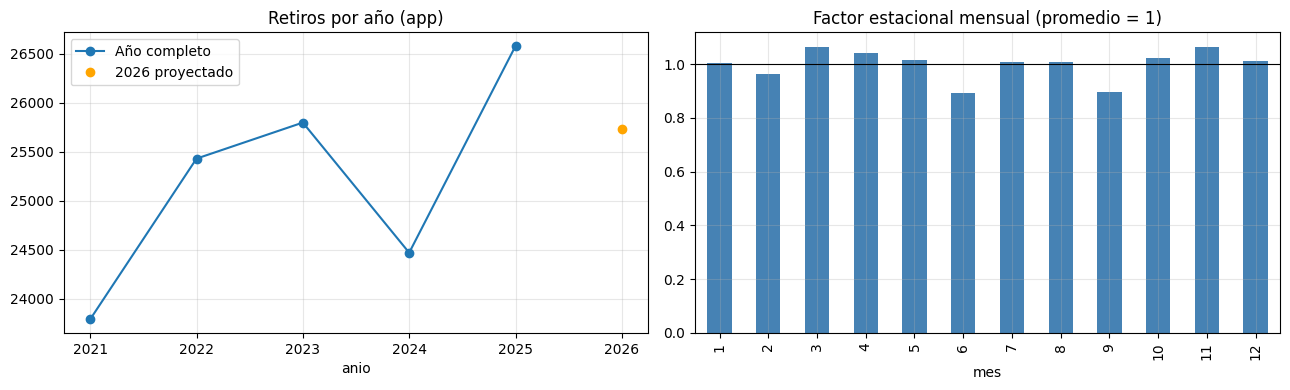

In [6]:
r = ret.groupby(['anio','mes']).retiros.sum().unstack()
anual = r.sum(axis=1); meses_2026 = r.loc[2026].notna().sum()
completo = r.loc[2021:2025]
estac = completo.div(completo.mean(axis=1), axis=0).mean(); estac = estac / estac.mean()
anual_2026_proy = r.loc[2026].sum() / estac.iloc[:meses_2026].sum() * 12
cagr = (anual.loc[2025] / anual.loc[2021]) ** (1/4) - 1
tab = pd.DataFrame({'retiros_app': anual}); tab.loc[2026,'retiros_app_proy'] = anual_2026_proy
display(tab); print(f'CAGR retiros 2021-2025: {cagr:.2%} | meses con datos en 2026: {meses_2026}')
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
anual.loc[2021:2025].plot(marker='o', ax=ax[0], label='Año completo'); ax[0].plot([2026], [anual_2026_proy], 'o', color='orange', label='2026 proyectado')
ax[0].set_title('Retiros por año (app)'); ax[0].legend()
estac.plot(kind='bar', ax=ax[1], color='steelblue'); ax[1].axhline(1, color='k', lw=.8); ax[1].set_title('Factor estacional mensual (promedio = 1)')
plt.tight_layout(); plt.show()

### 3.2 Día de la semana, hora y contenedores (envíos ene-ago 2026)

dow,Lun,Mar,Mié,Jue,Vie,Sáb,Dom
viajes_medios,112.62,116.76,121.50,114.88,90.27,6.71,20.00
factor_modelo,112.69,116.86,121.34,114.93,90.48,6.31,0.00


CV diario: 0.212 (gamma 0.189) | contenedores 9 m3 43.6%, 10 m3 42.7%, otros 13.7%
Peso medio por viaje: 5.59 t (alternativas: 4,43 → ~125 mil t/año; 4,8 → ~135 mil t/año)


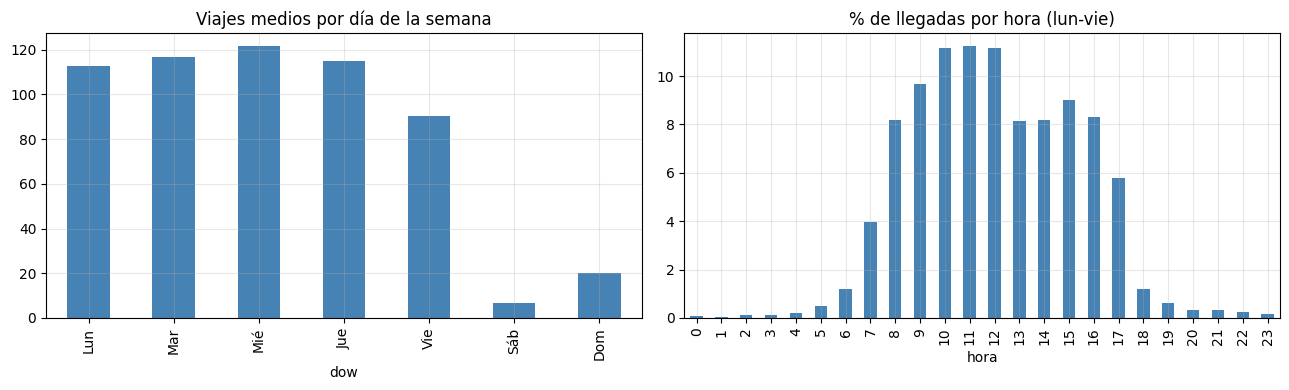

In [7]:
n = env[env.tipo_envio == 'normal'].copy()
n['fecha'] = pd.to_datetime(n.fecha)
n['hora'] = pd.to_datetime(n.hora_llegada_pozo, format='%I:%M %p', errors='coerce').dt.hour
n['dow'] = n.fecha.dt.dayofweek
dia = n.groupby('fecha').size().rename('viajes').to_frame()
dia['dow'] = dia.index.dayofweek; dia['mes'] = dia.index.month
dia['viajes_desest'] = dia.viajes / dia.mes.map(estac)
f_dow = dia.groupby('dow').viajes_desest.mean().reindex(range(7)).fillna(0)
cal = pd.date_range(dia.index.min(), dia.index.max())
cal = cal[[not (LLEG['usar_feriados'] and d in FERIADOS) for d in cal]]
for d_ in (5, 6):   # sábados/domingos: media por día calendario (incluye días sin viajes)
    f_dow[d_] = dia[dia.dow == d_].viajes_desest.sum() / max(sum(1 for d in cal if d.dayofweek == d_), 1)
if not LLEG['domingos_operan']: f_dow[6] = 0.0
nombres = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
hab = dia[dia.dow < 5]
cv_dia = (hab.viajes / (hab.dow.map(f_dow) * hab.mes.map(estac))).std()
cv_gamma = np.sqrt(max(cv_dia**2 - 1/hab.viajes.mean(), 0))
perfil_lv  = n[n.dow < 5].hora.value_counts(normalize=True).reindex(range(24), fill_value=0)
perfil_sab = n[n.dow == 5].hora.value_counts(normalize=True).reindex(range(24), fill_value=0)
mix = n.tipo_contenedor_m3.value_counts(normalize=True); m3_tipos = mix.index.values.astype(float); p_tipos = mix.values
def t_base(m3): return np.where(m3 == 9, LLEG['t_contenedor_9'], np.where(m3 == 10, LLEG['t_contenedor_10'], m3 * LLEG['dens_otros']))
t_viaje_contenedores = (t_base(m3_tipos) * p_tipos).sum()
esc_peso = 1.0 if LLEG['t_por_viaje_objetivo'] is None else LLEG['t_por_viaje_objetivo'] / t_viaje_contenedores
def t_esperado(m3): return t_base(m3) * esc_peso
t_viaje_medio = (t_esperado(m3_tipos) * p_tipos).sum()
m3_viaje_medio = (m3_tipos * p_tipos).sum() * LLEG['factor_llenado']
display(pd.DataFrame({'viajes_medios': dia.groupby('dow').viajes.mean().reindex(range(7)), 'factor_modelo': f_dow}).rename(index=dict(enumerate(nombres))).T)
print(f'CV diario: {cv_dia:.3f} (gamma {cv_gamma:.3f}) | contenedores 9 m3 {mix.get(9.0,0):.1%}, 10 m3 {mix.get(10.0,0):.1%}, otros {1-mix.get(9.0,0)-mix.get(10.0,0):.1%}')
print(f'Peso medio por viaje: {t_viaje_medio:.2f} t (alternativas: 4,43 → ~125 mil t/año; 4,8 → ~135 mil t/año)')
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
dia.groupby('dow').viajes.mean().reindex(range(7)).rename(index=dict(enumerate(nombres))).plot(kind='bar', ax=ax[0], color='steelblue', title='Viajes medios por día de la semana')
(perfil_lv*100).plot(kind='bar', ax=ax[1], color='steelblue', title='% de llegadas por hora (lun-vie)'); plt.tight_layout(); plt.show()

### 3.3 Calibración del nivel de llegadas

In [8]:
meses_env = sorted(n.fecha.dt.month.unique())
viajes_2026 = len(n) / estac.loc[meses_env].sum() * 12
g = cagr if LLEG['crecimiento'] is None else LLEG['crecimiento']
habiles_2026 = [d for d in pd.date_range('2026-01-01','2026-12-31') if not (LLEG['usar_feriados'] and d in FERIADOS)]
k_base = viajes_2026 / np.array([f_dow[d.dayofweek] * estac[d.month] for d in habiles_2026]).sum()
print(f'Viajes 2026 (envíos, anualizado): {viajes_2026:,.0f} | crecimiento: {g:.2%}/año | escala: {k_base:.3f}')

Viajes 2026 (envíos, anualizado): 28,206 | crecimiento: 2.81%/año | escala: 0.997


### 3.4 Materiales recuperados hoy (registro limpio v2)

In [9]:
mm_ = mat[mat.incluir_modelo].copy()
trips = (r.stack().dropna() * len(n) / r.loc[2026, meses_env].sum())         # viajes/mes a nivel envíos
trips.index.names = ['anio','mes']
rec_hist = mm_.groupby(['material','anio','mes']).agg(t=('t','sum'), clp=('monto_clp','sum')).reset_index()
rec_hist = rec_hist.merge(trips.rename('viajes').reset_index(), on=['anio','mes'])
rec_hist['kg_viaje'] = rec_hist.t * 1000 / rec_hist.viajes
tabla_kgv = rec_hist.groupby(['material','anio']).kg_viaje.mean().unstack().round(2)
display(tabla_kgv.rename_axis(index='kg recuperados por viaje'))
print('La caída de madera y cartón en 2025-26 es por decisión de REGEMAC (dejó de priorizarlos), no por menor contenido.')

anio,2024,2025,2026
kg recuperados por viaje,,,
aluminio,0.19,0.18,0.19
carton,1.85,1.06,0.40
fierro,18.76,18.91,20.90
madera,26.25,8.66,4.91
neumaticos,NaN,0.59,NaN
plastico,0.77,0.59,NaN


La caída de madera y cartón en 2025-26 es por decisión de REGEMAC (dejó de priorizarlos), no por menor contenido.


## 4. Funciones del modelo

In [10]:
def simular_llegadas(seed=None, detalle_horario=False, fecha_ini=None, fecha_fin=None):
    rng = np.random.default_rng(seed)
    fechas = pd.date_range(fecha_ini or f"{SIM['anio_inicio']}-01-01", fecha_fin or f"{SIM['anio_inicio']+SIM['horizonte']-1}-12-31")
    ok = np.array([not (LLEG['usar_feriados'] and d in FERIADOS) for d in fechas])
    dow = fechas.dayofweek.values; mes = fechas.month.values; anio = fechas.year.values
    sh = 1 / cv_gamma**2
    lam = k_base * f_dow.values[dow] * estac.loc[mes].values * (1 + g) ** (anio - 2026) * ok * rng.gamma(sh, 1/sh, len(fechas))
    viajes = rng.poisson(lam)
    cont = rng.multinomial(viajes, p_tipos)
    t_mean = t_esperado(m3_tipos)
    sd = np.sqrt(cont @ (LLEG['cv_peso_viaje'] * t_mean) ** 2)
    df = pd.DataFrame({'fecha': fechas, 'anio': anio, 'mes': mes, 'dow': dow, 'viajes': viajes,
                       'entrada_t': np.maximum(cont @ t_mean + rng.standard_normal(len(fechas)) * sd, 0),
                       'entrada_m3': cont @ m3_tipos * LLEG['factor_llenado']})
    if not detalle_horario: return df
    perf = np.where(dow[:, None] == 5, perfil_sab.values, perfil_lv.values)
    return df, pd.DataFrame([rng.multinomial(v, p) for v, p in zip(viajes, perf)], index=fechas, columns=range(24))

def sortear_contenido(rng):
    c = {m: (rng.triangular(*COMP['contenido'][m]) if COMP['muestrear'] else COMP['contenido'][m][1]) for m in COMP['contenido']}
    c['inertes'] = 1 - sum(c.values()); return c

def precios_mensuales(rng, n_mes):
    out = {}
    for m, p0 in MERCADO['precio'].items():
        z = np.zeros(n_mes)
        for k in range(1, n_mes): z[k] = MERCADO['reversion'] * z[k-1] + MERCADO['vol_mensual'][m] * rng.standard_normal()
        out[m] = p0 * np.exp(z)
    rc = MERCADO['riesgo_comprador']
    if rc['usar']:      # episodios en que se pierde al comprador único: el precio cae 'descuento' durante 'meses'
        ev = rng.random(n_mes) < rc['prob_anual'] / 12
        caida = np.zeros(n_mes, bool)
        for k in np.flatnonzero(ev): caida[k:k + rc['meses']] = True
        for m in rc['materiales']: out[m] = np.where(caida, out[m] * (1 - rc['descuento']), out[m])
    return out

def acopio_no_permitidos(ingreso, reglas):
    # Acopio FIFO diario con reglas propias del escenario. Devuelve stock y salidas al vertedero (por tiempo / exceso).
    lotes, n_d = [], len(ingreso)
    stock, s_t, s_e = np.zeros(n_d), np.zeros(n_d), np.zeros(n_d)
    for i in range(n_d):
        if ingreso[i] > 0: lotes.append([i, ingreso[i]])
        if reglas['usar_limite_tiempo']:
            while lotes and i - lotes[0][0] >= reglas['dias_max']: s_t[i] += lotes.pop(0)[1]
        tot = sum(l[1] for l in lotes)
        if reglas['usar_limite_stock'] and tot > reglas['stock_max_t']:
            exc = tot - reglas['stock_max_t']; s_e[i] = exc
            while exc > 1e-9:
                q = min(lotes[0][1], exc); lotes[0][1] -= q; exc -= q
                if lotes[0][1] <= 1e-9: lotes.pop(0)
            tot = reglas['stock_max_t']
        stock[i] = tot
    return stock, s_t, s_e

try:
    from numba import njit
except ImportError:
    njit = lambda f: f
@njit
def cola_planta(arr, cap, max_h, max_t, usar_t, usar_s):
    # Modo 'reglas' (v0.5) – acopio FIFO por hora: llega arr[h], se procesa hasta cap[h]; salen al vertedero cohortes con antigüedad ≥ max_h o el exceso sobre max_t.
    n = len(arr); coh = np.zeros(n); head = 0; stock = 0.0
    proc = np.zeros(n); d_t = np.zeros(n); d_s = np.zeros(n); st = np.zeros(n)
    for h in range(n):
        coh[h] = arr[h]; stock += arr[h]
        c = cap[h]
        while c > 1e-12 and head <= h:
            q = min(coh[head], c); coh[head] -= q; c -= q; stock -= q; proc[h] += q
            if coh[head] <= 1e-12: head += 1
        if usar_t:
            while head <= h and h - head >= max_h:
                d_t[h] += coh[head]; stock -= coh[head]; coh[head] = 0.0; head += 1
        if usar_s and stock > max_t:
            exc = stock - max_t; d_s[h] = exc
            while exc > 1e-12 and head <= h:
                q = min(coh[head], exc); coh[head] -= q; exc -= q; stock -= q
                if coh[head] <= 1e-12: head += 1
        st[h] = stock
    return proc, d_t, d_s, st

@njit
def cola_control(arr, cap, trab, obj, kp, base, cap_v, ret, tope):
    # Acopio de espera FIFO por hora con vaciado controlado:
    #  1) llega arr[h]; si el acopio supera el tope, lo que llega se descarga directo en el vertedero (desvío)
    #  2) la planta procesa hasta cap[h] (lo más antiguo primero)
    #  3) en horas de trabajo (trab[h]=1) se vacía al vertedero: base + kp·(acopio observado − objetivo), entre 0 y cap_v
    n = len(arr); coh = np.zeros(n); head = 0; stock = 0.0
    proc = np.zeros(n); d_v = np.zeros(n); d_s = np.zeros(n); st = np.zeros(n)
    for h in range(n):
        coh[h] = arr[h]; stock += arr[h]
        if stock > tope:
            q = min(stock - tope, coh[h]); coh[h] -= q; stock -= q; d_s[h] = q
        c = cap[h]
        while c > 1e-12 and head <= h:
            q = min(coh[head], c); coh[head] -= q; c -= q; stock -= q; proc[h] += q
            if coh[head] <= 1e-12: head += 1
        if trab[h] > 0:
            s_obs = st[h - ret] if (ret > 0 and h - ret >= 0) else stock
            v = min(max(base + kp * (s_obs - obj), 0.0), cap_v, stock)
            d_v[h] = v
            while v > 1e-12 and head <= h:
                q = min(coh[head], v); coh[head] -= q; v -= q; stock -= q
                if coh[head] <= 1e-12: head += 1
        st[h] = stock
    return proc, d_v, d_s, st

def dens_inertes(cont, f=1.0):
    # Densidad de 'inertes' tal que la mezcla calce con la densidad media recibida (f escala esa densidad, ver con_densidad).
    rho_mix = t_viaje_medio / m3_viaje_medio * f
    resto = 1 / rho_mix - sum(cont[m] / DENS[m] for m in DENS)
    return max(cont['inertes'] / max(resto, 1e-6), 0.4)

def volumen(masas, cont):
    d = dict(DENS, inertes=dens_inertes(cont))
    return sum(masas[m] / d[m] for m in masas)

def preparar_corrida(seed):
    # Sorteos comunes a todos los escenarios (números aleatorios comunes): llegadas por hora, contenido, precios.
    rng = np.random.default_rng(seed)
    lleg, hor = simular_llegadas(seed=seed, detalle_horario=True)
    v = lleg.viajes.values.astype(float)
    t_h = np.divide(lleg.entrada_t.values, v, out=np.zeros_like(v), where=v > 0)[:, None] * hor.values
    cont = sortear_contenido(rng)
    meses = (lleg.anio.values - lleg.anio.values[0]) * 12 + lleg.mes.values - 1
    precios = {m: s_[meses] for m, s_ in precios_mensuales(rng, meses.max() + 1).items()}
    mult = {m: rng.gamma(1/cv**2, cv**2, meses.max() + 1)[meses] for m, cv in BASE['cv_mensual'].items()}
    return dict(lleg=lleg, t_h=t_h, cont=cont, precios=precios, mult=mult, meses=meses, f_dens=1.0)

def con_densidad(cr, rho):
    # Misma historia, pero con otra densidad media de lo recibido (t/m3): mismos viajes y m3, más o menos toneladas.
    f = rho / (t_viaje_medio / m3_viaje_medio)
    lleg = cr['lleg'].copy(); lleg['entrada_t'] = lleg.entrada_t * f
    return dict(cr, lleg=lleg, t_h=cr['t_h'] * f, f_dens=f)

# tasa de extracción manual por trabajador (t/h), calibrada con 2026
_h26 = sum(1 for d in habiles_2026 if d.dayofweek in BASE['dias']) * len(BASE['horas'])
TASA_EXTR = {m: kg / 1000 * viajes_2026 / _h26 / BASE['trabajadores'] for m, kg in BASE['kg_viaje_2026'].items()}

def extraccion_manual(E_dia, lleg, trabajadores, cr, horas, dias):
    # t/día que sacan los trabajadores del frente de descarga: mín(capacidad, CAPTURA_MAX_FOSA × lo que llegó).
    h_dia = np.where(np.isin(lleg.dow.values, dias) & (lleg.viajes.values > 0), len(horas), 0)
    anio_rel = lleg.anio.values - lleg.anio.values[0]
    R = {}
    for m in MAT:
        if m not in TASA_EXTR or trabajadores == 0: R[m] = np.zeros(len(lleg)); continue
        tend = (1 + BASE['tendencia_anual'].get(m, 0)) ** anio_rel
        cap = trabajadores * TASA_EXTR[m] * h_dia * cr['mult'][m] * tend
        R[m] = np.minimum(cap, CAPTURA_MAX_FOSA * E_dia[m])
    return R

def cerrar_balance(o, lleg, cont, R, E_vert_np_dia, vert_perm_mat, sep_np, sc, cr, extra=None):
    # Arma columnas comunes: acopio NP, vertedero (t y m3), ahorro, ingresos y costos.
    st, s_t, s_e = acopio_no_permitidos(sep_np, sc['acopio_np'])
    o['acopio_np_ingreso_t'] = sep_np; o['acopio_np_stock_t'] = st; o['acopio_np_a_vert_t'] = s_t + s_e
    o['vert_permitido_t'] = sum(vert_perm_mat.values())
    o['vert_noperm_t'] = sum(E_vert_np_dia.values()) + s_t + s_e
    o['vertedero_t'] = o.vert_permitido_t + o.vert_noperm_t
    for m in MAT: o[f'rec_{m}_t'] = R[m]
    o['recuperado_t'] = sum(R.values())
    # volumen: materiales al vertedero con su densidad; lo del acopio NP con densidad media de lo separado
    d = dict(DENS, inertes=dens_inertes(cont, cr.get('f_dens', 1.0)))
    v_np = sum(E_vert_np_dia[m] / d[m] for m in E_vert_np_dia)
    v_perm = sum(vert_perm_mat[m] / d[m] for m in vert_perm_mat)
    o['vertedero_m3'] = v_perm + v_np + (s_t + s_e) / d['yeso']
    # ahorro = lo que entró y NO terminó en el vertedero ni quedó en inventario (acopio de espera / acopio NP)
    inv_m3 = (extra['acopio_espera_m3'] if extra and 'acopio_espera_m3' in extra else 0) + st / d['yeso']
    o['ahorro_vertedero_m3'] = o.entrada_m3 - o.vertedero_m3 - np.diff(np.asarray(inv_m3, dtype=float) + np.zeros(len(o)), prepend=0)
    pr = cr['precios']
    o['ingresos_metales_clp'] = sum(R[m] * 1000 * pr[m] for m in pr if sc['vende'].get(m, False))
    for k, v in flujo_madera(R['madera'], sc).items(): o[k] = v
    o['ingresos_clp'] = o.ingresos_metales_clp + o.ingreso_astilla_clp
    o['costo_madera_clp'] = o.costo_recupac_clp + o.costo_flete_astilla_clp + o.costo_chipeo_clp
    o['neto_materiales_clp'] = o.ingresos_clp - o.costo_madera_clp
    for c_ in ['vertedero_t','vertedero_m3','vert_noperm_t','recuperado_t','ahorro_vertedero_m3']: o[f'acum_{c_}'] = o[c_].cumsum()
    if extra:
        for k, v in extra.items(): o[k] = v
    return o

# ---------- Bloques del CBO: imán, madera/astilla, costos ----------
def iman_de(sc):
    # Imán del escenario: el propio, o el del CBO si el escenario hereda las mejoras del CBO.
    if 'iman' in sc: return sc['iman']
    return CBO['iman'] if sc.get('mejoras_cbo') else None

def madera_de(sc):
    if 'madera' in sc: return sc['madera']
    return CBO['madera'] if sc.get('mejoras_cbo') else {'destino': 'recupac'}

def aplicar_iman(E_f, R, cr, sc):
    # Fierro (t/día) que saca el imán: r × (fracción de lo del día que llega en las horas del imán) × fierro que dejaron los trabajadores.
    # Suma a R['fierro'] respetando el tope técnico CAPTURA_MAX_FOSA. Devuelve lo aportado por el imán.
    im = iman_de(sc); n_d = len(E_f)
    if not im or not im['usar']: return np.zeros(n_d)
    t_h = cr['t_h']; tot = t_h.sum(axis=1)
    w = np.divide(t_h[:, im['horas']].sum(axis=1), tot, out=np.zeros(n_d), where=tot > 0)
    dia_ok = np.isin(cr['lleg'].dow.values, BASE['dias'])
    resto = np.maximum(E_f - R['fierro'], 0)
    R_im = np.minimum(im['recuperacion'] * w * resto * dia_ok, np.maximum(CAPTURA_MAX_FOSA * E_f - R['fierro'], 0))
    R['fierro'] = R['fierro'] + R_im
    return R_im

def campanas_chipeo(apta, modo):
    # Arriendo (Raico): la madera se junta hasta completar un lote (o hasta que pasan dias_max) y se chipea en una campaña.
    p = MADERA['chipeo'][modo]; n_d = len(apta)
    chip, costo = np.zeros(n_d), np.zeros(n_d); stock, edad = 0.0, 0
    for i in range(n_d):
        stock += apta[i]; edad = edad + 1 if stock > 0 else 0
        if stock > 0 and (stock >= p['lote_min_t'] or edad >= p['dias_max'] or i == n_d - 1):
            chip[i] = stock
            costo[i] = np.ceil(stock / p['t_semana']) * p['uf_semana'] * COSTOS['uf']   # semanas de arriendo Raico
            stock, edad = 0.0, 0
    return chip, costo

def flujo_madera(Rm, sc):
    # Destino de la madera recuperada (t/día) → t a RECUPAC, t de astilla y sus ingresos/costos ($/día).
    md_ = madera_de(sc); n_d = len(Rm)
    out = dict(t_recupac=np.asarray(Rm, float).copy(), t_astilla=np.zeros(n_d), ingreso_astilla_clp=np.zeros(n_d),
               costo_flete_astilla_clp=np.zeros(n_d), costo_chipeo_clp=np.zeros(n_d))
    if md_['destino'] == 'astilla':
        apta = Rm * MADERA['frac_apta']; out['t_recupac'] = Rm - apta
        modo = md_['modo_chipeo']
        if modo == 'compra':
            p = MADERA['chipeo']['compra']
            chip, costo = apta, apta / p['cap_th'] * p['factor_horas'] * p['kw'] * p['carga'] * COSTOS['precio_kwh']
        else:
            chip, costo = campanas_chipeo(apta, modo)
        out.update(t_astilla=chip, costo_chipeo_clp=costo, ingreso_astilla_clp=chip * MADERA['precio_astilla'],
                   costo_flete_astilla_clp=chip * MADERA['flete_astilla'])
    out['costo_recupac_clp'] = out['t_recupac'] * 1000 * MERCADO['costo_recupac']
    return out

def personal_extra(sc):
    if 'operarios_picking' in sc:
        return (sc['operarios_picking'] + sc['operarios_apoyo']) * sc.get('turnos', 1) + sc['trabajadores_fosa'] - BASE['trabajadores']
    return sc.get('trabajadores_extra', 0)

def capex(sc):
    # Inversión del escenario (CLP), por ítem.
    it = {}
    im = iman_de(sc)
    if im and im['usar']: it['Electroimán'] = im['capex_usd'] * (1 + COSTOS['internacion']) * COSTOS['tc_usd']
    if 'capex_gbp' in sc:
        it['Planta (cotización)'] = sc['capex_gbp'] * COSTOS['tc_gbp']
        it['Obras civiles, grúa, tablero'] = it['Planta (cotización)'] * sc['pct_obras']
    md_ = madera_de(sc)
    if md_['destino'] == 'astilla' and md_['modo_chipeo'] == 'compra': it['Chipeadora'] = MADERA['chipeo']['compra']['capex_clp']
    return it

def costo_mov_t():
    return MOVIMIENTO['diesel_lh'] * COSTOS['precio_diesel'] / MOVIMIENTO['t_por_hora']

def agregar_opex(o, sc, es_planta=False):
    # Costos de operación ($/día): adicionales a los de hoy + movimiento al pozo (en todos). Resultado operativo = neto materiales − OPEX.
    n_d = len(o); dia_op = (np.isin(o.dow.values, BASE['dias']) & (o.viajes.values > 0)).astype(float)
    fac = COSTOS['factor_costo_empresa'] * 12 / 365
    o['opex_personal_clp'] = (personal_extra(sc) * COSTOS['sueldo_operario_mes'] + sc.get('supervisores_extra', 0) * sc.get('turnos', 1) * COSTOS['sueldo_supervisor_mes']) * fac
    energia, diesel, mant = np.zeros(n_d), np.zeros(n_d), np.zeros(n_d)
    im = iman_de(sc); cx = capex(sc)
    if im and im['usar']:
        diesel += dia_op * len(im['horas']) * im['diesel_lh'] * im['frac_diesel_incremental'] * COSTOS['precio_diesel']
        mant += cx['Electroimán'] * im['mantencion'] / 365
    if es_planta:
        h = o.horas_op.values
        if sc.get('energia', 'red') == 'generador':       # generador diésel 60 kVA (FT620C): 9,5 L/h al 50% de carga (ficha Kiverco)
            diesel += h * sc['generador_lh'] * COSTOS['precio_diesel']
        else:
            energia += h * sc['kw'] * sc['carga_electrica'] * COSTOS['precio_kwh']
        if sc.get('alimentacion', 'por_tonelada') == 'por_hora':            # cargador dedicado a la tolva todo el turno
            alim = h * sc['cargador_lh'] * COSTOS['precio_diesel']
        else:                                                              # por tonelada cargada a la tolva
            alim = o.procesado_t.values * costo_mov_t() * sc.get('factor_alimentacion', 1.0)
        o['opex_alimentacion_clp'] = alim; diesel += alim
        mant += (cx['Planta (cotización)'] + cx['Obras civiles, grúa, tablero']) * sc['mantencion'] / 365
    if 'Chipeadora' in cx: mant += cx['Chipeadora'] * MADERA['chipeo']['compra']['mantencion'] / 365
    # movimiento al pozo (TODOS los escenarios): todo lo que termina en el vertedero se mueve una vez con retro/cargador
    o['opex_movimiento_clp'] = o.vertedero_t.values * costo_mov_t(); diesel += o.opex_movimiento_clp.values
    if 'opex_alimentacion_clp' not in o: o['opex_alimentacion_clp'] = 0.0
    o['opex_energia_clp'], o['opex_diesel_clp'], o['opex_mantencion_clp'] = energia, diesel, mant
    o['opex_clp'] = o.opex_personal_clp + energia + diesel + mant
    o['resultado_operativo_clp'] = o.neto_materiales_clp - o.opex_clp
    return o

def caso_fosa(cr, sc):
    # Caso base y CBO: todo se descarga en la fosa; los trabajadores (y el imán, si hay) sacan material; el resto va al vertedero.
    sc = {**BASE, **sc}                          # lo que el escenario no define se toma del caso base
    lleg, cont = cr['lleg'], cr['cont']
    E = {m: lleg.entrada_t.values * cont[m] for m in MAT}
    R = extraccion_manual(E, lleg, sc['trabajadores'] + sc.get('trabajadores_extra', 0), cr, sc['horas'], sc['dias'])
    R_im = aplicar_iman(E['fierro'], R, cr, sc)
    if madera_de(sc)['destino'] == 'fosa': R['madera'] = np.zeros(len(lleg))
    no_rec = {m: E[m] - R[m] for m in MAT}
    np_mats = [m for m in MAT if not PERMITIDO_VERTEDERO[m]]
    sep = sum(no_rec[m] for m in np_mats) * sc['frac_no_permitido_apartado']
    E_vert_np = {m: no_rec[m] * (1 - sc['frac_no_permitido_apartado']) for m in np_mats}
    vert_perm = {m: no_rec[m] for m in MAT if PERMITIDO_VERTEDERO[m]}
    o = lleg.copy(); o['procesado_t'] = 0.0; o['bypass_t'] = 0.0; o['acopio_espera_m3'] = 0.0
    o = cerrar_balance(o, lleg, cont, R, E_vert_np, vert_perm, sep, sc, cr, {'rec_fierro_iman_t': R_im})
    return agregar_opex(o, sc)

def caso_base(cr): return caso_fosa(cr, BASE)
def caso_cbo(cr, sc=None): return caso_fosa(cr, sc or CBO)

def horas_operacion(lleg, sc):
    # Matriz días × 24 con 1 en horas de operación de la planta.
    op = np.zeros((len(lleg), 24))
    dia_ok = np.isin(lleg.dow.values, sc['dias']) & np.array([not (LLEG['usar_feriados'] and d in FERIADOS) for d in lleg.fecha])
    op[np.ix_(dia_ok, sc['horas'])] = 1.0
    return op

def capacidad_th(sc):
    c_maq = sc['cap_nominal_th'] * sc['factor_densidad'] * sc['disponibilidad']
    c_op = sc['operarios_picking'] * sc['tasa_revision_th'] / sc['fraccion_a_picking']
    return min(c_maq, c_op), c_maq, c_op

def caso_planta(cr, sc):
    lleg, cont, t_h = cr['lleg'], cr['cont'], cr['t_h']
    n_d = len(lleg); cap, c_maq, c_op = capacidad_th(sc)
    cap_h = (horas_operacion(lleg, sc) * cap).ravel()
    rho = t_viaje_medio / m3_viaje_medio * cr.get('f_dens', 1.0)
    p = sc['acopio_espera']; arr = t_h.ravel()
    if p['modo'] == 'control':
        trab = horas_operacion(lleg, dict(sc, horas=p['horas_vaciado'] or sc['horas'])).ravel()
        base = max(arr.sum() - cap_h.sum(), 0) / max(trab.sum(), 1) if p['tasa_base'] == 'auto' else p['tasa_base']
        proc, d_v, d_s, st = cola_control(arr, cap_h, trab, p['objetivo_m3'] * rho, p['kp'], base, p['cap_vaciado_th'], p['retardo_h'], p['tope_m3'] * rho)
    else:
        proc, d_v, d_s, st = cola_planta(arr, cap_h, p['horas_max'], p['tope_m3'] * rho, p['usar_limite_tiempo'], True)
        d_v = d_v + d_s; d_s = np.zeros_like(d_s); base = np.nan      # en 'reglas' todo sale del montón (remanejo)
    dia = lambda x: x.reshape(n_d, 24).sum(axis=1)
    P_d, B_d = dia(proc), dia(d_v) + dia(d_s)          # procesado / al vertedero sin procesar (t/día)
    sin_mat = ((cap_h > 0) & (proc < cap_h - 1e-9)).astype(float)   # horas de turno en que la planta se quedó sin material
    # material procesado
    Rp = {m: P_d * cont[m] * sc['captura'].get(m, 0) for m in MAT}
    # lo no procesado: extracción manual opcional en la fosa
    Eb = {m: B_d * cont[m] for m in MAT}
    Rb = extraccion_manual(Eb, lleg, sc['trabajadores_fosa'], cr, BASE['horas'], BASE['dias'])
    R_im = aplicar_iman(Eb['fierro'], Rb, cr, sc)       # imán de la retro sobre lo no procesado (si mejoras_cbo)
    R = {m: Rp[m] + Rb[m] for m in MAT}
    # destinos
    sep_np = Rp['yeso'] + sum(Rp[m] for m in ['plastico','carton','aluminio'] if not sc['vende'].get(m, False))
    for m in ['yeso'] + [m for m in ['plastico','carton','aluminio'] if not sc['vende'].get(m, False)]: R[m] = np.zeros(n_d) + Rb[m]
    dest_mad = madera_de(sc)['destino']
    if dest_mad == 'fosa': R['madera'] = Rb['madera']
    np_mats = [m for m in MAT if not PERMITIDO_VERTEDERO[m]]
    E_vert_np = {m: (P_d * cont[m] - Rp[m]) + (Eb[m] - Rb[m]) + (Rp['madera'] if (m == 'madera' and dest_mad == 'fosa') else 0) for m in np_mats}
    vert_perm = {m: P_d * cont[m] + Eb[m] - Rb[m] for m in MAT if PERMITIDO_VERTEDERO[m]}
    o = lleg.copy()
    extra = {'procesado_t': P_d, 'bypass_t': B_d, 'vaciado_t': dia(d_v), 'desvio_tope_t': dia(d_s), 'horas_sin_material': dia(sin_mat),
             'acopio_espera_m3': st.reshape(n_d, 24)[:, -1] / rho, 'acopio_espera_max_m3': st.reshape(n_d, 24).max(axis=1) / rho,
             'horas_op': horas_operacion(lleg, sc).sum(axis=1), 'rec_fierro_iman_t': R_im}
    o = cerrar_balance(o, lleg, cont, R, E_vert_np, vert_perm, sep_np, sc, cr, extra)
    o = agregar_opex(o, sc, es_planta=True)
    o.attrs.update(cap=cap, c_maq=c_maq, c_op=c_op, acopio_h=st / rho, vaciado_h=d_v, desvio_h=d_s, proc_h=proc, tasa_base=base)
    return o

def resumen(o):
    a = o.groupby('anio').agg(entrada_t=('entrada_t','sum'), procesado_t=('procesado_t','sum'), bypass_t=('bypass_t','sum'),
        recuperado_t=('recuperado_t','sum'), fierro_t=('rec_fierro_t','sum'), madera_t=('rec_madera_t','sum'),
        vertedero_t=('vertedero_t','sum'), vert_permitido_t=('vert_permitido_t','sum'), vert_noperm_t=('vert_noperm_t','sum'), vertedero_m3=('vertedero_m3','sum'),
        ahorro_m3=('ahorro_vertedero_m3','sum'), iman_t=('rec_fierro_iman_t','sum'), astilla_t=('t_astilla','sum'),
        ingresos_clp=('ingresos_clp','sum'), costo_madera_clp=('costo_madera_clp','sum'), neto_clp=('neto_materiales_clp','sum'),
        opex_clp=('opex_clp','sum'), opex_energia_clp=('opex_energia_clp','sum'), opex_mov_clp=('opex_movimiento_clp','sum'), opex_alim_clp=('opex_alimentacion_clp','sum'), resultado_clp=('resultado_operativo_clp','sum'),
        acopio_max_m3=('acopio_espera_m3','max'))
    a['pct_procesado'] = a.procesado_t / a.entrada_t
    a['pct_recuperado'] = a.recuperado_t / a.entrada_t       # Rodrigo: % de recuperación sobre lo recibido (medido 2025: ~0,7%)
    return a

def anios_pozo(r_, r0):
    # Años de vida útil del pozo que se ganan: m3 que se dejaron de disponer en el horizonte ÷ m3 que se disponen por año al final (caso de referencia).
    # Es una razón: no depende del factor de compactación si es el mismo en ambos escenarios.
    return (r0.vertedero_m3 - r_.vertedero_m3).sum() / r0.vertedero_m3.iloc[-1]

def delta(r_, r0):
    # Diferencia anual entre dos escenarios (r_ − r0), en unidades legibles.
    return pd.DataFrame({'Δ fierro (t)': r_.fierro_t - r0.fierro_t, 'Δ fierro imán (t)': r_.iman_t - r0.iman_t,
        'Δ madera (t)': r_.madera_t - r0.madera_t, 'Δ astilla (t)': r_.astilla_t - r0.astilla_t,
        'Δ NO permitido al vertedero (t)': r_.vert_noperm_t - r0.vert_noperm_t, 'Δ m3 ahorrados': r_.ahorro_m3 - r0.ahorro_m3,
        'Δ neto materiales ($MM)': (r_.neto_clp - r0.neto_clp)/1e6, 'Δ OPEX ($MM)': (r_.opex_clp - r0.opex_clp)/1e6,
        'Δ mov. al pozo ($MM)': (r_.opex_mov_clp - r0.opex_mov_clp)/1e6, 'Δ alimentación planta ($MM)': (r_.opex_alim_clp - r0.opex_alim_clp)/1e6,
        'Δ resultado operativo ($MM)': (r_.resultado_clp - r0.resultado_clp)/1e6})

### 4.1 Densidades por material (t → m3)
Cada tonelada que sale del pozo (vendida, a RECUPAC o astilla) ahorra el volumen que **ese material** ocuparía, no el del RCD promedio. La tabla muestra los m3 por tonelada y el aporte de cada material al volumen de un m3 de RCD recibido, con la composición en su moda.

In [11]:
c_moda = {m: v[1] for m, v in COMP['contenido'].items()}; c_moda['inertes'] = 1 - sum(c_moda.values())
d_ = dict(DENS, inertes=dens_inertes(c_moda))
tab_d = pd.DataFrame({'densidad (t/m3)': d_, 'm3 por t': {m: 1/v for m, v in d_.items()}, '% masa (moda)': c_moda})
tab_d['% del volumen'] = tab_d['% masa (moda)'] * tab_d['m3 por t'] / (tab_d['% masa (moda)'] * tab_d['m3 por t']).sum()
display(tab_d.style.format({'densidad (t/m3)': '{:.2f}', 'm3 por t': '{:.2f}', '% masa (moda)': '{:.2%}', '% del volumen': '{:.1%}'}))
print(f'Densidad de la mezcla recibida: {t_viaje_medio/m3_viaje_medio:.3f} t/m3 → inertes {d_["inertes"]:.2f} t/m3 (NCh3562 Tabla D.3: inerte limpio 1,24; con esponjamiento ≥30%)')
print('Ojo: son densidades de residuo SUELTO. En el pozo el material se compacta; el m3 de pozo ahorrado real depende de esa compactación (dato a pedir a Rodrigo).')

,densidad (t/m3),m3 por t,% masa (moda),% del volumen
fierro,0.42,2.38,1.50%,1.9%
aluminio,0.90,1.11,0.05%,0.0%
madera,0.34,2.94,2.50%,3.9%
carton,0.05,20.00,0.50%,5.2%
plastico,0.21,4.76,1.00%,2.5%
yeso,0.33,3.03,5.40%,8.6%
inertes,0.60,1.67,89.05%,77.9%


Densidad de la mezcla recibida: 0.525 t/m3 → inertes 0.60 t/m3 (NCh3562 Tabla D.3: inerte limpio 1,24; con esponjamiento ≥30%)
Ojo: son densidades de residuo SUELTO. En el pozo el material se compacta; el m3 de pozo ahorrado real depende de esa compactación (dato a pedir a Rodrigo).


## 5. Llegadas: validación y real vs simulado

In [12]:
lleg, horario = simular_llegadas(seed=SIM['semilla'], detalle_horario=True)
sim_hab = lleg[(lleg.dow < 5) & (lleg.viajes > 0) & (lleg.anio == SIM['anio_inicio'])]
display(pd.DataFrame({'real 2026': [hab.viajes.mean(), hab.viajes.std(), hab.viajes.quantile(.95)],
                      f"simulado {SIM['anio_inicio']}": [sim_hab.viajes.mean(), sim_hab.viajes.std(), sim_hab.viajes.quantile(.95)]},
                     index=['media viajes/día (lun-vie)', 'desv. estándar', 'P95']))

,real 2026,simulado 2027
media viajes/día (lun-vie),111.29,113.84
desv. estándar,25.38,26.45
P95,150.10,165.50


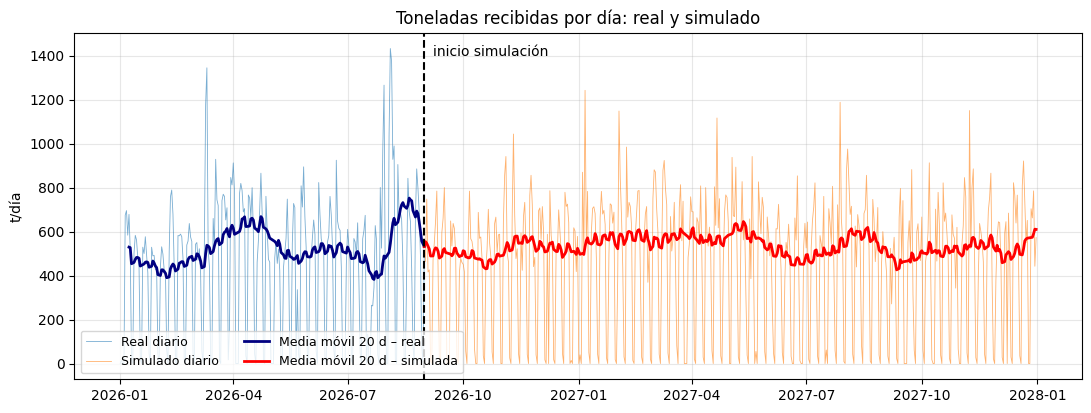

In [13]:
# 5.1 Diario: real ene-ago 2026 + simulado desde sep-2026 (media móvil 20 días)
n['t_viaje'] = t_esperado(n.tipo_contenedor_m3.fillna(9).astype(float).values)
real_d = n.groupby('fecha').agg(t=('t_viaje','sum')).t
real_d = real_d.reindex(pd.date_range('2026-01-01', real_d.index.max()), fill_value=0)
corte = real_d.index.max()
sim_d = simular_llegadas(seed=SIM['semilla'], fecha_ini=corte + pd.Timedelta(days=1), fecha_fin='2027-12-31').set_index('fecha').entrada_t
s_all = pd.concat([real_d, sim_d]); mmv = s_all[s_all > 0].rolling(20, min_periods=5).mean()
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(real_d.index, real_d, lw=.6, alpha=.6, color='tab:blue', label='Real diario'); ax.plot(sim_d.index, sim_d, lw=.6, alpha=.6, color='tab:orange', label='Simulado diario')
ax.plot(mmv[:corte].index, mmv[:corte], color='navy', lw=2, label='Media móvil 20 d – real'); ax.plot(mmv[corte:].index, mmv[corte:], color='red', lw=2, label='Media móvil 20 d – simulada')
ax.axvline(corte, color='k', ls='--'); ax.annotate('inicio simulación', (corte, ax.get_ylim()[1]*.93), xytext=(6, 0), textcoords='offset points')
ax.set_title('Toneladas recibidas por día: real y simulado'); ax.set_ylabel('t/día'); ax.legend(loc='lower left', ncol=2, fontsize=9); plt.show()

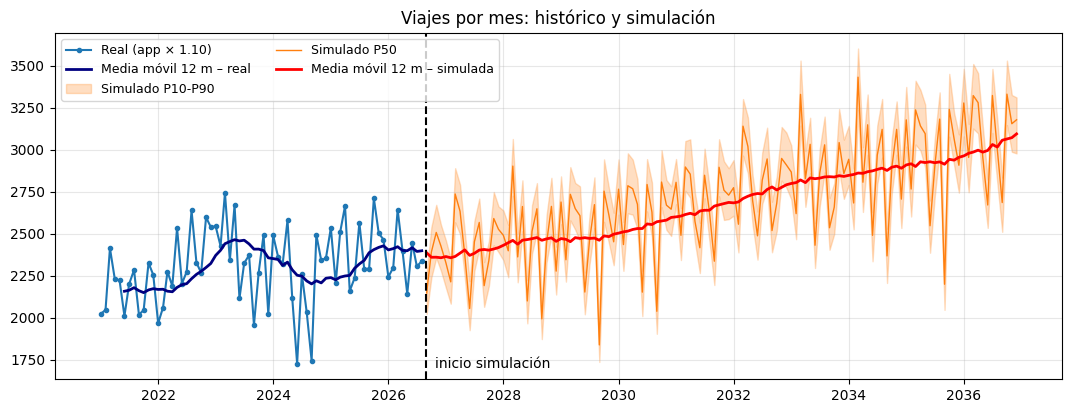

In [14]:
# 5.2 Mensual 2021-2036 con banda P10-P90 (200 corridas)
esc_app = len(n) / r.loc[2026, meses_env].sum()
real_m = r.stack().dropna() * esc_app; real_m.index = pd.to_datetime([f'{a}-{m:02d}-01' for a, m in real_m.index]); real_m = real_m[real_m.index <= corte]
fin = f"{SIM['anio_inicio']+SIM['horizonte']-1}-12-31"
corr = pd.concat([simular_llegadas(seed=1000+i, fecha_ini=corte + pd.Timedelta(days=1), fecha_fin=fin).set_index('fecha').viajes.resample('MS').sum() for i in range(200)], axis=1)
band = corr.quantile([.1, .5, .9], axis=1).T
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(real_m.index, real_m, color='tab:blue', marker='.', label=f'Real (app × {esc_app:.2f})'); ax.plot(real_m.index, real_m.rolling(12, min_periods=6).mean(), color='navy', lw=2, label='Media móvil 12 m – real')
ax.fill_between(band.index, band[.1], band[.9], color='tab:orange', alpha=.25, label='Simulado P10-P90'); ax.plot(band.index, band[.5], color='tab:orange', lw=1, label='Simulado P50')
mm2 = pd.concat([real_m, band[.5]]).rolling(12, min_periods=6).mean(); ax.plot(mm2[band.index.min():].index, mm2[band.index.min():], color='red', lw=2, label='Media móvil 12 m – simulada')
ax.axvline(corte, color='k', ls='--'); ax.annotate('inicio simulación', (corte, ax.get_ylim()[0]), xytext=(6, 8), textcoords='offset points')
ax.set_title('Viajes por mes: histórico y simulación'); ax.legend(loc='upper left', ncol=2, fontsize=9); plt.show()

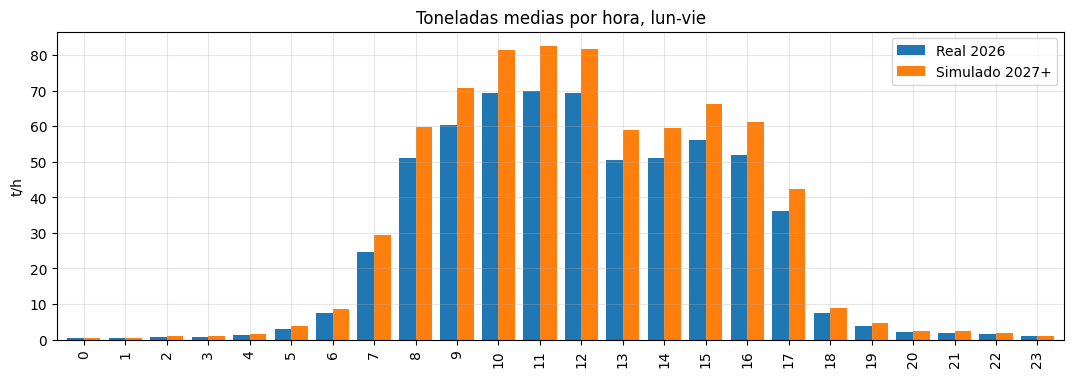

In [15]:
# 5.3 Perfil horario lun-vie: real vs simulado
hs = horario[(horario.index.dayofweek < 5) & (horario.sum(axis=1) > 0)]
real_h = n[n.dow < 5].groupby(['fecha','hora']).size().unstack(fill_value=0).reindex(columns=range(24), fill_value=0).mean()
pd.DataFrame({'Real 2026': real_h * t_viaje_medio, f"Simulado {SIM['anio_inicio']}+": hs.mean() * t_viaje_medio}).plot(kind='bar', figsize=(13, 4), width=.8, color=['tab:blue','tab:orange'])
plt.title('Toneladas medias por hora, lun-vie'); plt.ylabel('t/h'); plt.show()

## 6. Una corrida de todos los escenarios (mismas llegadas, composición y precios)
Primero se sortea una "historia" de 10 años (`cr`): camiones por hora, contenido de cada material y precios mensuales. Después cada escenario se aplica a esa misma historia.

In [16]:
cr = preparar_corrida(SIM['semilla'])
print('Contenido sorteado (% masa):', {k: f'{v:.2%}' for k, v in cr['cont'].items()}, f"| densidad inertes: {dens_inertes(cr['cont']):.2f} t/m3")
ESC = {'Caso base': caso_base(cr), 'CBO': caso_cbo(cr)}
SC_DE = {'Caso base': BASE, 'CBO': CBO}            # parámetros de cada escenario (para CAPEX)
for k, sc in PLANTAS.items():
    ESC[sc['nombre']] = caso_planta(cr, sc); SC_DE[sc['nombre']] = sc
    c, cm, co = capacidad_th(sc)
    print(f"{sc['nombre']}: capacidad efectiva {c:.1f} t/h  (máquina {cm:.1f} | operarios {co:.1f})  → {'manda la MÁQUINA' if cm <= co else 'mandan los OPERARIOS'}")
R_ = {k: resumen(o) for k, o in ESC.items()}       # resumen anual de cada escenario
DIAS = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

Contenido sorteado (% masa): {'fierro': '2.07%', 'aluminio': '0.07%', 'madera': '4.37%', 'carton': '1.06%', 'plastico': '0.60%', 'yeso': '6.61%', 'inertes': '85.23%'} | densidad inertes: 0.66 t/m3
Planta KS514: capacidad efectiva 30.4 t/h  (máquina 30.4 | operarios 106.7)  → manda la MÁQUINA
Planta FT620C + PS123: capacidad efectiva 26.8 t/h  (máquina 26.8 | operarios 58.2)  → manda la MÁQUINA


### 6.1 Caso base: validación contra los datos de REGEMAC
Datos de Rodrigo (9-oct): ventas de reciclaje $108,7 MM en 2025 y $81,4 MM entre enero y agosto de 2026; madera a RECUPAC 258 t en 2025 y 93 t entre enero y agosto de 2026; lo que efectivamente salió del pozo en 2025 suma ~875 t, alrededor de **0,7% de lo recibido**. El 3% es una estimación de la operación y se usa como escenario, no como dato.

In [17]:
b1 = R_['Caso base'].iloc[0]
display(pd.DataFrame({'REGEMAC 2026 (ene-ago × 12/8)': [401.0*12/8, 93*12/8, 81.4*12/8, np.nan],
                      'REGEMAC 2025': [np.nan, 258, 108.7, 0.007],
                      f"simulado {SIM['anio_inicio']}": [b1.fierro_t, b1.madera_t, b1.ingresos_clp/1e6, b1.pct_recuperado]},
                     index=['fierro vendido (t)', 'madera a RECUPAC (t)', 'ventas reciclaje ($ MM)', '% recuperado sobre lo recibido']).style.format('{:,.1f}', na_rep='—').format('{:.2%}', subset=pd.IndexSlice['% recuperado sobre lo recibido', :], na_rep='—'))
print('El modelo recupera algo menos que el 0,7% medido porque el registro limpio solo cuenta lo vendido (fierro, aluminio, cartón) y la madera;')
print('las ~875 t de Rodrigo incluyen material separado que no se vende de inmediato (plástico, neumáticos).')
print('Capacidad de extracción por trabajador (t/h):', {m: round(v, 4) for m, v in TASA_EXTR.items()})

,REGEMAC 2026 (ene-ago × 12/8),REGEMAC 2025,simulado 2027
fierro vendido (t),601.5,—,560.3
madera a RECUPAC (t),139.5,258.0,133.2
ventas reciclaje ($ MM),122.1,108.7,122.0
% recuperado sobre lo recibido,—,0.70%,0.44%


El modelo recupera algo menos que el 0,7% medido porque el registro limpio solo cuenta lo vendido (fierro, aluminio, cartón) y la madera;
las ~875 t de Rodrigo incluyen material separado que no se vende de inmediato (plástico, neumáticos).
Capacidad de extracción por trabajador (t/h): {'fierro': np.float64(0.0328), 'aluminio': np.float64(0.0003), 'madera': np.float64(0.0078), 'carton': np.float64(0.0006), 'plastico': np.float64(0.0)}


### 6.2 CBO: qué agregan el imán y la chipeadora
**Cómo leerlo:**
- **Imán.** Muestra cuánto fierro adicional saca el imán y cuántos años tarda en pagarse solo.
- **Madera.** Compara las salidas posibles: seguir pagando a RECUPAC, comprar chipeadora o arrendar a Raico. El resultado operativo ya descuenta flete, chipeo y mantención.

Ojo con la opción "todo el turno" del imán: supone que la retro se dedica al imán y deja de hacer su trabajo actual, y que el imán no compite con los trabajadores. Es un techo optimista.

In [18]:
rb, rc = R_['Caso base'], R_['CBO']
d_cbo = delta(rc, rb)
print('CBO − Caso base, promedio anual 10 años:'); display(d_cbo.mean().to_frame('promedio').T.round(1))
cx_cbo = capex(CBO); print('CAPEX CBO ($):', {k: f'{v:,.0f}' for k, v in cx_cbo.items()})
print(f"Fierro que llega al año: {(ESC['CBO'].entrada_t * cr['cont']['fierro']).sum()/SIM['horizonte']:,.0f} t | lo saca la gente: {rb.fierro_t.mean():,.0f} t | el imán agrega: {rc.iman_t.mean():,.0f} t")

CBO − Caso base, promedio anual 10 años:


,Δ fierro (t),Δ fierro imán (t),Δ madera (t),Δ astilla (t),Δ NO permitido al vertedero (t),Δ m3 ahorrados,Δ neto materiales ($MM),Δ OPEX ($MM),Δ mov. al pozo ($MM),Δ alimentación planta ($MM),Δ resultado operativo ($MM)
promedio,88.30,88.30,0.00,93.90,-88.30,216.00,18.30,8.00,-0.00,0.00,10.30


CAPEX CBO ($): {'Electroimán': '17,100,000', 'Chipeadora': '30,975,000'}
Fierro que llega al año: 3,808 t | lo saca la gente: 580 t | el imán agrega: 88 t


In [19]:
# 6.2a Sensibilidad del imán (como en el Excel de Nicolás): recuperación r × horas de trabajo del imán (sin chipeadora, para aislar el imán)
filas = []
for r_ in (0.12, 0.20, 0.30, 0.50):
    for etiqueta, horas in [('valle 13 y 17 h', [13, 17]), ('valle + 2 h', [12, 13, 17, 18]), ('todo el turno', list(range(8, 18)))]:
        sc2 = dict(CBO, iman=dict(CBO['iman'], recuperacion=r_, horas=horas), madera=BASE['madera'])
        d_ = delta(resumen(caso_cbo(cr, sc2)), rb).mean()
        inv = sum(capex(sc2).values()) / 1e6
        filas.append({'r': r_, 'horas imán': etiqueta, 'Δ fierro imán (t/año)': d_['Δ fierro imán (t)'],
                      'Δ resultado ($MM/año)': d_['Δ resultado operativo ($MM)'], 'CAPEX ($MM)': inv,
                      'payback (años)': inv / d_['Δ resultado operativo ($MM)'] if d_['Δ resultado operativo ($MM)'] > 0 else np.nan})
display(pd.DataFrame(filas).style.format({'r': '{:.0%}', 'Δ fierro imán (t/año)': '{:,.0f}', 'Δ resultado ($MM/año)': '{:,.1f}', 'CAPEX ($MM)': '{:,.1f}', 'payback (años)': '{:.1f}'}))

,r,horas imán,Δ fierro imán (t/año),Δ resultado ($MM/año),CAPEX ($MM),payback (años)
0,12%,valle 13 y 17 h,53,5.1,17.1,3.3
1,12%,valle + 2 h,100,10.0,17.1,1.7
2,12%,todo el turno,347,44.6,17.1,0.4
3,20%,valle 13 y 17 h,88,11.8,17.1,1.4
4,20%,valle + 2 h,167,22.7,17.1,0.8
5,20%,todo el turno,579,88.7,17.1,0.2
6,30%,valle 13 y 17 h,132,20.2,17.1,0.8
7,30%,valle + 2 h,251,38.6,17.1,0.4
8,30%,todo el turno,868,143.7,17.1,0.1
9,50%,valle 13 y 17 h,221,37.0,17.1,0.5


In [20]:
# 6.2b Destino de la madera: RECUPAC vs astilla (compra / arriendo Raico), en el CBO y en la planta KS514
OPC_MADERA = {'RECUPAC (hoy)': dict(destino='recupac'), 'Astilla – compra chipeadora': dict(destino='astilla', modo_chipeo='compra'),
              'Astilla – arriendo Raico': dict(destino='astilla', modo_chipeo='arriendo')}
filas = []
for esc, f_ in [('CBO', lambda m: caso_cbo(cr, dict(CBO, madera=m))), ('Planta KS514', lambda m: caso_planta(cr, dict(PLANTAS['KS514'], madera=m)))]:
    for k, m in OPC_MADERA.items():
        o = f_(m); a = resumen(o).mean(); sc_ = dict(CBO, madera=m)
        cm = (o.costo_madera_clp.sum() - o.ingreso_astilla_clp.sum()) / max(o.rec_madera_t.sum(), 1e-9)
        filas.append({'escenario': esc, 'destino madera': k, 'madera recuperada (t/año)': a.madera_t, 'astilla (t/año)': a.astilla_t,
                      'costo neto madera ($/t)': cm, 'CAPEX chipeadora ($MM)': capex(sc_).get('Chipeadora', 0)/1e6,
                      'resultado operativo ($MM/año)': a.resultado_clp/1e6})
tm = pd.DataFrame(filas)
display(tm.style.format({c: '{:,.0f}' for c in tm.columns if c not in ('escenario', 'destino madera')} | {'resultado operativo ($MM/año)': '{:,.1f}', 'CAPEX chipeadora ($MM)': '{:,.1f}'}))
print('Costo neto madera = (RECUPAC + flete + chipeo − venta astilla) / t recuperada; negativo = la madera deja plata. No incluye mantención ni CAPEX de la chipeadora.')
print('Arriendo Raico: 400 UF por semana (35 h, ~700 t). Con poca madera se paga la semana completa por un lote chico.')

,escenario,destino madera,madera recuperada (t/año),astilla (t/año),costo neto madera ($/t),CAPEX chipeadora ($MM),resultado operativo ($MM/año)
0,CBO,RECUPAC (hoy),134,0,"15,126",0.0,81.7
1,CBO,Astilla – compra chipeadora,134,94,"3,701",31.0,80.1
2,CBO,Astilla – arriendo Raico,134,94,"120,867",0.0,67.5
3,Planta KS514,RECUPAC (hoy),"1,848",0,"15,126",0.0,103.2
4,Planta KS514,Astilla – compra chipeadora,"1,848","1,294","3,701",31.0,121.2
5,Planta KS514,Astilla – arriendo Raico,"1,848","1,294","31,154",0.0,73.6


Costo neto madera = (RECUPAC + flete + chipeo − venta astilla) / t recuperada; negativo = la madera deja plata. No incluye mantención ni CAPEX de la chipeadora.
Arriendo Raico: 400 UF por semana (35 h, ~700 t). Con poca madera se paga la semana completa por un lote chico.


### 6.3 Plantas: una semana típica
**Arriba:** t/h que llegan (barras), capacidad de la línea (verde, solo en horas de turno) y lo que se vacía del acopio al vertedero sin procesar (naranjo, solo en horario laboral).
**Abajo:** m³ en el acopio de espera (el montón frente a la planta) y el objetivo que buscan mantener los trabajadores. El montón sube cuando llega más de lo que se procesa y vacía, se queda quieto de noche y el fin de semana, y vuelve al objetivo durante el día.

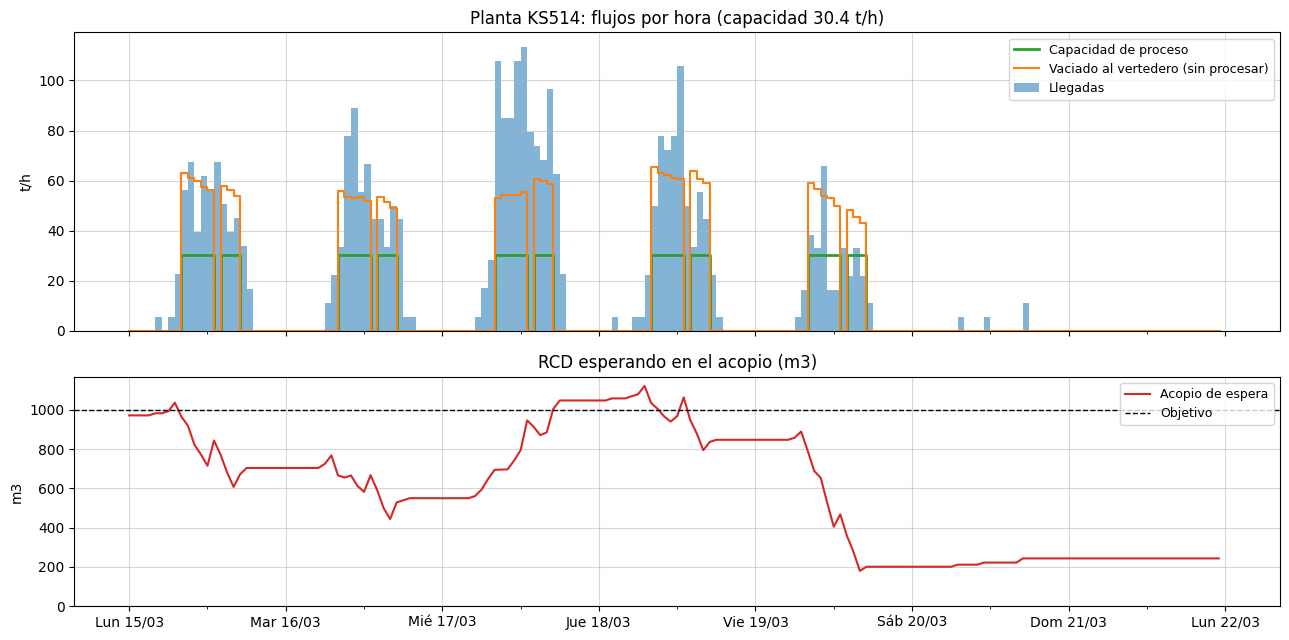

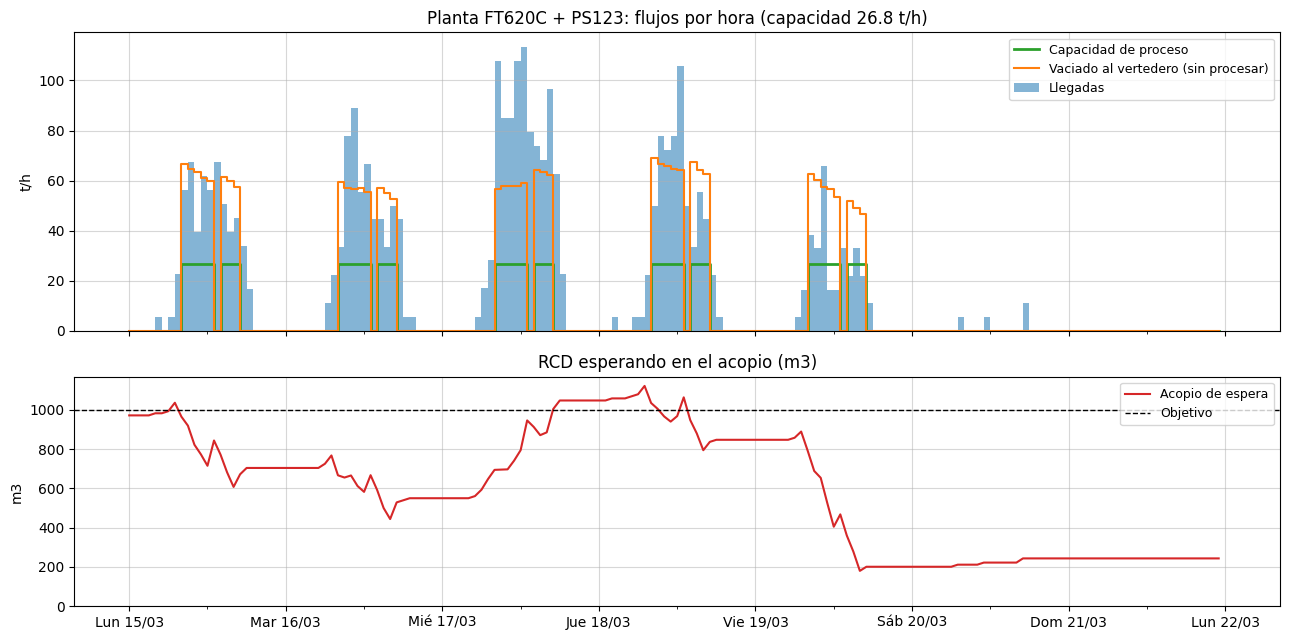

In [21]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
t_idx = pd.date_range(f"{SIM['anio_inicio']}-01-01", periods=len(cr['t_h'].ravel()), freq='h')
d0 = 70 + (7 - t_idx[70*24].dayofweek) % 7                 # primer lunes desde el día 70 (mediados de marzo)
sem = slice(d0*24, (d0+7)*24); horas_idx = t_idx[sem]
fmt_dia = FuncFormatter(lambda x, _: (lambda d: f"{DIAS[d.weekday()]} {d.day:02d}/{d.month:02d}")(mdates.num2date(x)))
for k, sc in PLANTAS.items():
    o = ESC[sc['nombre']]; p = sc['acopio_espera']
    cap_h = (horas_operacion(cr['lleg'], sc) * o.attrs['cap']).ravel()[sem]
    fig, ax = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True, gridspec_kw={'height_ratios': [1.3, 1]})
    ax[0].bar(horas_idx, cr['t_h'].ravel()[sem], width=1/24, align='edge', color='tab:blue', alpha=.55, label='Llegadas')
    ax[0].step(horas_idx, cap_h, where='post', color='tab:green', lw=2, label='Capacidad de proceso')
    ax[0].step(horas_idx, o.attrs['vaciado_h'][sem], where='post', color='tab:orange', lw=1.5, label='Vaciado al vertedero (sin procesar)')
    ax[0].set_ylabel('t/h'); ax[0].legend(loc='upper right', fontsize=9); ax[0].set_title(f"{sc['nombre']}: flujos por hora (capacidad {o.attrs['cap']:.1f} t/h)")
    ax[1].plot(horas_idx, o.attrs['acopio_h'][sem], color='tab:red', label='Acopio de espera')
    if p['modo'] == 'control': ax[1].axhline(p['objetivo_m3'], ls='--', color='k', lw=1, label='Objetivo')
    ax[1].set_ylabel('m3'); ax[1].set_ylim(bottom=0); ax[1].legend(loc='upper right', fontsize=9); ax[1].set_title('RCD esperando en el acopio (m3)')
    for a_ in ax:
        a_.xaxis.set_major_locator(mdates.DayLocator()); a_.xaxis.set_major_formatter(fmt_dia)
        a_.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12])); a_.grid(True, which='major', alpha=.5)
    plt.tight_layout(); plt.show()

### 6.4 Acopio de espera a lo largo del horizonte: ¿por qué un vaciado que reacciona?
Se compara la **tasa fija** (`kp = 0`, alternativa simple) con el **vaciado que reacciona** al tamaño del montón (`kp > 0`).

Con tasa fija, el balance cuadra solo en el promedio de los 10 años. Como las llegadas crecen ~2,8% al año, en los primeros años se vacía de más (el montón queda casi vacío y la planta a veces se queda sin material) y en los últimos se vacía de menos (el montón crece hasta el tope y los camiones se desvían).

Con reacción, el montón vuelve al objetivo en cualquier año. La tabla de abajo muestra que el valor del objetivo casi no cambia lo procesado, siempre que no sea tan chico que la planta se quede sin material al partir el turno.

**Restricción de Rodrigo:** el acopio temporal no puede pasar de 7.500 m³, por espacio, permisos y riesgo (`tope_m3`).

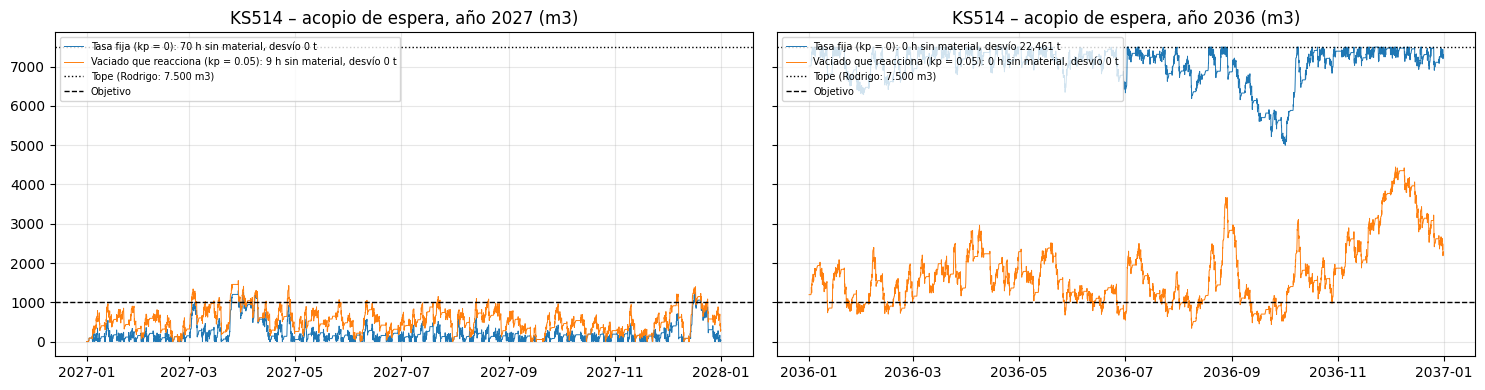

,objetivo (m3),kp,% procesado,horas sin material/año,acopio máx (m3),desvío por tope (t/año)
0,250,0.020000,32.7%,24,"4,661",0
1,250,0.050000,32.7%,26,"4,257",0
2,250,0.200000,32.8%,17,"3,988",0
3,500,0.020000,32.8%,20,"4,827",0
4,500,0.050000,32.8%,15,"4,474",0
5,500,0.200000,32.8%,1,"4,237",0
6,1000,0.020000,32.8%,12,"5,327",0
7,1000,0.050000,32.8%,2,"4,963",0
8,1000,0.200000,32.8%,0,"4,737",0
9,2000,0.020000,32.8%,1,"6,327",0


In [22]:
sc0 = PLANTAS['KS514']
fig, ax = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
for etiqueta, kp, col in [('Tasa fija (kp = 0)', 0.0, 'tab:blue'), (f"Vaciado que reacciona (kp = {sc0['acopio_espera']['kp']})", sc0['acopio_espera']['kp'], 'tab:orange')]:
    o_ = caso_planta(cr, dict(sc0, acopio_espera=dict(sc0['acopio_espera'], kp=kp)))
    for a_, anio in zip(ax, (SIM['anio_inicio'], SIM['anio_inicio'] + SIM['horizonte'] - 1)):
        m_ = t_idx.year == anio; y_ = o_[o_.anio == anio]
        a_.plot(t_idx[m_], o_.attrs['acopio_h'][m_], lw=.7, color=col,
                label=f"{etiqueta}: {y_.horas_sin_material.sum():,.0f} h sin material, desvío {y_.desvio_tope_t.sum():,.0f} t")
for a_, anio in zip(ax, (SIM['anio_inicio'], SIM['anio_inicio'] + SIM['horizonte'] - 1)):
    a_.axhline(sc0['acopio_espera']['tope_m3'], color='k', ls=':', lw=1, label='Tope (Rodrigo: 7.500 m3)'); a_.axhline(sc0['acopio_espera']['objetivo_m3'], color='k', ls='--', lw=1, label='Objetivo')
    a_.set_title(f'KS514 – acopio de espera, año {anio} (m3)'); a_.legend(fontsize=7, loc='upper left')
plt.tight_layout(); plt.show()
filas = []
for obj in (250, 500, 1000, 2000, 4000):
    for kp in (0.02, 0.05, 0.2):
        o_ = caso_planta(cr, dict(sc0, acopio_espera=dict(sc0['acopio_espera'], objetivo_m3=obj, kp=kp)))
        filas.append({'objetivo (m3)': obj, 'kp': kp, '% procesado': o_.procesado_t.sum()/o_.entrada_t.sum(),
                      'horas sin material/año': o_.horas_sin_material.sum()/SIM['horizonte'], 'acopio máx (m3)': o_.attrs['acopio_h'].max(),
                      'desvío por tope (t/año)': o_.desvio_tope_t.sum()/SIM['horizonte']})
display(pd.DataFrame(filas).style.format({'% procesado': '{:.1%}', 'horas sin material/año': '{:,.0f}', 'acopio máx (m3)': '{:,.0f}', 'desvío por tope (t/año)': '{:,.0f}'}))

### 6.5 Comparación de todos los escenarios contra el caso base
Primero, la foto de cada escenario (promedio anual en 10 años). Después, la diferencia de cada uno contra el caso base, con:
- **Payback simple:** CAPEX ÷ Δ resultado operativo promedio. No descuenta ni considera impuestos.
- **Años de pozo ganados:** m³ que se dejaron de disponer en 10 años ÷ m³ que se disponen por año al final del horizonte. Rodrigo cree que es el principal beneficio.
- **Valor del m³ para recuperar el CAPEX en 10 años:** cuánto tendría que valer cada m³ de pozo ahorrado. Es el dato que hay que pedirle a Rodrigo.
- **Costo por t procesada:** (OPEX adicional + CAPEX ÷ 10) ÷ t procesadas. Se compara con lo que cuesta hoy disponer 1 t (movimiento $/t + valor del espacio, este último pendiente).

,entrada_t,procesado_t,pct_procesado,recuperado_t,pct_recuperado,fierro_t,iman_t,madera_t,astilla_t,vert_noperm_t,vertedero_m3,neto_clp,opex_clp,resultado_clp
Caso base,"184,253",0,0.0%,731,0.40%,580,0,134,0,"26,470","345,982","118,049,622","48,173,400","69,876,222"
CBO,"184,253",0,0.0%,819,0.45%,669,88,134,94,"26,382","345,766","136,345,748","56,214,474","80,131,274"
Planta KS514,"184,253","60,486",33.1%,"3,667",2.00%,"1,196",71,"1,848","1,294","23,515","333,910","305,427,574","184,209,224","121,218,349"
Planta FT620C + PS123,"184,253","53,322",29.2%,"3,027",1.65%,"1,011",75,"1,513","1,059","24,137","336,767","254,848,830","165,905,328","88,943,502"


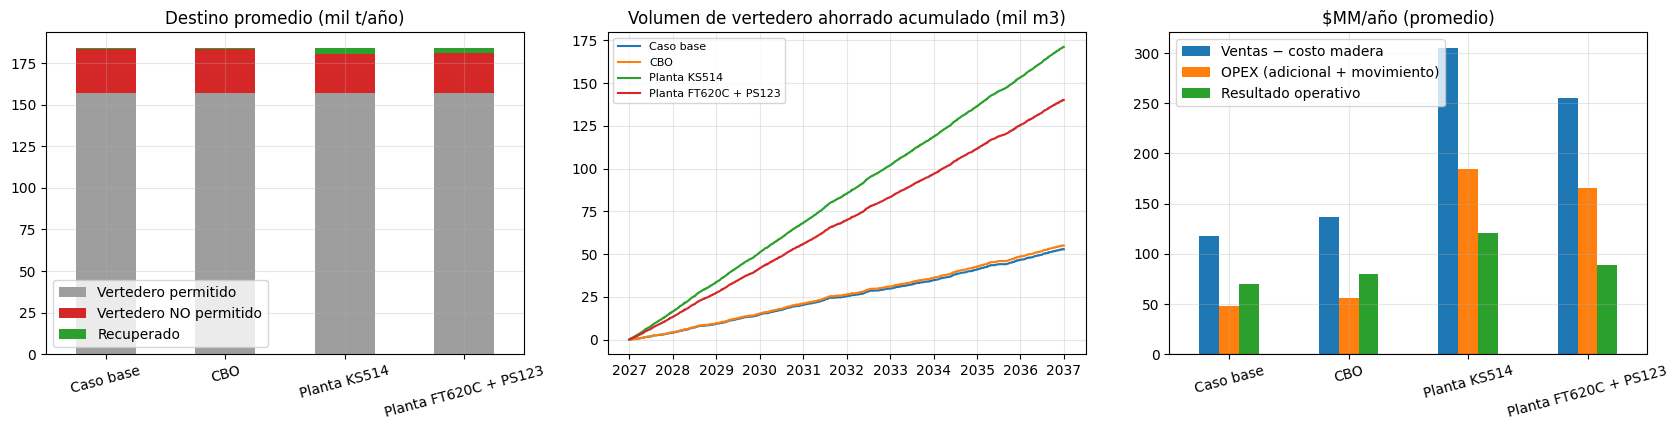

In [23]:
comp = pd.concat({k: r_.mean() for k, r_ in R_.items()}, axis=1).T
cols = ['entrada_t','procesado_t','pct_procesado','recuperado_t','pct_recuperado','fierro_t','iman_t','madera_t','astilla_t','vert_noperm_t','vertedero_m3','neto_clp','opex_clp','resultado_clp']
display(comp[cols].style.format({'pct_procesado':'{:.1%}', 'pct_recuperado':'{:.2%}', **{c:'{:,.0f}' for c in cols if c not in ('pct_procesado','pct_recuperado')}}))
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
dest = pd.DataFrame({k: [o.vert_permitido_t.sum(), o.vert_noperm_t.sum(), o.recuperado_t.sum()] for k, o in ESC.items()}, index=['Vertedero permitido','Vertedero NO permitido','Recuperado']).T/1e3/SIM['horizonte']
dest.plot(kind='bar', stacked=True, ax=ax[0], color=['#9e9e9e','#d62728','#2ca02c'], rot=15); ax[0].set_title('Destino promedio (mil t/año)')
for k, o in ESC.items(): ax[1].plot(o.fecha, o.acum_ahorro_vertedero_m3/1e3, label=k)
ax[1].set_title('Volumen de vertedero ahorrado acumulado (mil m3)'); ax[1].legend(fontsize=8)
(comp[['neto_clp','opex_clp','resultado_clp']]/1e6).rename(columns={'neto_clp':'Ventas − costo madera','opex_clp':'OPEX (adicional + movimiento)','resultado_clp':'Resultado operativo'}).plot(kind='bar', ax=ax[2], rot=15)
ax[2].axhline(0, color='k', lw=.8); ax[2].set_title('$MM/año (promedio)')
plt.tight_layout(); plt.show()

In [24]:
def indicadores(nom, ref):
    r_, r0 = R_[nom], R_[ref]; d_ = delta(r_, r0)
    cx = sum(capex(SC_DE[nom]).values()) - sum(capex(SC_DE[ref]).values())
    dr = d_['Δ resultado operativo ($MM)'].mean() * 1e6; dm3 = d_['Δ m3 ahorrados'].mean()
    proc = r_.procesado_t.mean()
    return {'comparación': f'{nom} vs {ref}', 'CAPEX incremental ($MM)': cx/1e6, 'Δ resultado operativo ($MM/año)': dr/1e6,
            'payback simple (años)': cx / dr if dr > 0 else np.nan, 'Δ % recuperado (pp)': (r_.pct_recuperado - r0.pct_recuperado).mean()*100,
            'Δ m3 ahorrados/año': dm3, 'años de pozo ganados': anios_pozo(r_, r0),
            'valor m3 para recuperar CAPEX en 10 años ($/m3)': max(cx - dr * SIM['horizonte'], 0) / (dm3 * SIM['horizonte']) if dm3 > 0 else np.nan,
            'costo por t procesada ($/t)': ((r_.opex_clp - r0.opex_clp).mean() + cx / SIM['horizonte']) / proc if proc > 0 else np.nan}
FMT_IND = {'Δ m3 ahorrados/año': '{:,.0f}', 'valor m3 para recuperar CAPEX en 10 años ($/m3)': '{:,.0f}', 'costo por t procesada ($/t)': '{:,.0f}',
           'años de pozo ganados': '{:.2f}', 'Δ % recuperado (pp)': '{:.2f}'}
inc_base = {f'{k} vs Caso base': delta(R_[k], R_['Caso base']) for k in ESC if k != 'Caso base'}
ind_base = pd.DataFrame([indicadores(k, 'Caso base') for k in ESC if k != 'Caso base']).set_index('comparación')
display(ind_base.style.format('{:,.1f}').format(FMT_IND))
print(f"Costo actual de mover 1 t al pozo: ${costo_mov_t():,.0f}/t (+ valor del espacio de pozo que ocupa: pendiente, POZO['valor_m3'])")
for sc in PLANTAS.values():
    o = ESC[sc['nombre']]
    print(f"{sc['nombre']}: {sc['kw']} kW → {o.opex_energia_clp.sum() / COSTOS['precio_kwh'] / o.procesado_t.sum():.2f} kWh/t procesada (Ferronato, Excel de Pedro: 1,45-4,52)")
for k, d_ in inc_base.items():
    print(k); display(d_.round(1))

,CAPEX incremental ($MM),Δ resultado operativo ($MM/año),payback simple (años),Δ % recuperado (pp),Δ m3 ahorrados/año,años de pozo ganados,valor m3 para recuperar CAPEX en 10 años ($/m3),costo por t procesada ($/t)
comparación,,,,,,,,
CBO vs Caso base,48.075000,10.255052,4.687933,0.05,216,0.01,0,nan
Planta KS514 vs Caso base,1284.275000,51.342127,25.014059,1.60,"11,840",0.31,"6,511","4,372"
Planta FT620C + PS123 vs Caso base,790.075000,19.067279,41.436168,1.26,"8,737",0.24,"6,860","3,690"


Costo actual de mover 1 t al pozo: $262/t (+ valor del espacio de pozo que ocupa: pendiente, POZO['valor_m3'])
Planta KS514: 37 kW → 0.97 kWh/t procesada (Ferronato, Excel de Pedro: 1,45-4,52)
Planta FT620C + PS123: 46 kW → 1.37 kWh/t procesada (Ferronato, Excel de Pedro: 1,45-4,52)
CBO vs Caso base


,Δ fierro (t),Δ fierro imán (t),Δ madera (t),Δ astilla (t),Δ NO permitido al vertedero (t),Δ m3 ahorrados,Δ neto materiales ($MM),Δ OPEX ($MM),Δ mov. al pozo ($MM),Δ alimentación planta ($MM),Δ resultado operativo ($MM)
anio,,,,,,,,,,,
2027,76.10,76.10,0.00,93.20,-75.90,186.10,16.60,8.10,-0.00,0.00,8.50
2028,76.50,76.50,0.00,101.30,-76.60,187.20,16.80,8.00,-0.00,0.00,8.80
2029,78.10,78.10,0.00,86.70,-78.10,191.10,17.40,8.00,-0.00,0.00,9.40
2030,83.70,83.70,0.00,102.70,-83.80,204.80,18.90,8.00,-0.00,0.00,10.90
2031,87.00,87.00,0.00,87.70,-87.00,212.70,18.30,8.10,-0.00,0.00,10.30
2032,90.30,90.30,0.00,84.60,-90.40,220.80,18.80,8.10,-0.00,0.00,10.70
2033,90.90,90.90,0.00,107.50,-90.90,222.30,19.00,8.10,-0.00,0.00,10.90
2034,95.00,95.00,0.00,80.00,-94.90,232.50,17.60,8.00,-0.00,0.00,9.60
2035,101.30,101.30,0.00,108.60,-101.30,247.80,18.80,8.00,-0.00,0.00,10.90


Planta KS514 vs Caso base


,Δ fierro (t),Δ fierro imán (t),Δ madera (t),Δ astilla (t),Δ NO permitido al vertedero (t),Δ m3 ahorrados,Δ neto materiales ($MM),Δ OPEX ($MM),Δ mov. al pozo ($MM),Δ alimentación planta ($MM),Δ resultado operativo ($MM)
anio,,,,,,,,,,,
2027,630.00,57.70,"1,727.70","1,302.60","-3,007.80","12,329.30",195.40,136.20,-0.80,16.00,59.20
2028,589.50,59.10,"1,694.50","1,287.40","-2,887.70","12,026.90",190.10,136.10,-0.80,15.80,54.00
2029,585.00,60.70,"1,702.10","1,278.10","-2,968.70","11,911.60",188.90,135.40,-0.90,15.70,53.50
2030,573.20,68.20,"1,694.80","1,289.00","-2,820.40","11,701.10",185.40,136.00,-0.60,15.80,49.50
2031,645.60,68.00,"1,731.00","1,299.40","-3,019.50","12,023.90",186.20,136.00,-0.90,15.90,50.10
2032,660.10,72.20,"1,757.80","1,315.00","-3,047.90","12,149.90",204.50,136.80,-0.80,16.10,67.70
2033,597.20,73.90,"1,709.60","1,304.20","-2,906.90","11,766.50",193.70,136.30,-0.70,16.00,57.40
2034,586.40,78.70,"1,719.70","1,283.80","-2,902.00","11,563.20",168.70,135.70,-0.70,15.80,33.00
2035,623.70,83.50,"1,671.40","1,278.60","-2,896.00","11,260.60",169.50,135.60,-0.80,15.70,33.90


Planta FT620C + PS123 vs Caso base


,Δ fierro (t),Δ fierro imán (t),Δ madera (t),Δ astilla (t),Δ NO permitido al vertedero (t),Δ m3 ahorrados,Δ neto materiales ($MM),Δ OPEX ($MM),Δ mov. al pozo ($MM),Δ alimentación planta ($MM),Δ resultado operativo ($MM)
anio,,,,,,,,,,,
2027,444.80,61.80,"1,390.60","1,066.60","-2,350.30","9,209.60",142.90,117.90,-0.70,14.10,24.90
2028,406.40,63.10,"1,361.30","1,054.20","-2,253.80","8,943.60",138.00,117.80,-0.60,13.90,20.20
2029,403.10,64.80,"1,370.90","1,046.30","-2,337.20","8,847.30",136.70,117.20,-0.80,13.80,19.50
2030,389.50,72.30,"1,360.60","1,055.10","-2,185.30","8,608.50",132.70,117.70,-0.50,13.90,15.00
2031,460.40,72.00,"1,394.10","1,063.60","-2,383.20","8,906.20",136.50,117.80,-0.70,14.10,18.70
2032,472.70,76.40,"1,416.80","1,076.40","-2,388.50","8,995.10",151.00,118.50,-0.60,14.20,32.50
2033,411.40,78.00,"1,371.50","1,067.50","-2,261.60","8,637.80",140.70,118.00,-0.60,14.10,22.70
2034,403.60,82.90,"1,386.80","1,050.80","-2,268.90","8,483.20",122.70,117.50,-0.60,13.90,5.30
2035,441.40,87.50,"1,339.90","1,046.60","-2,326.20","8,192.60",124.50,117.20,-0.70,13.80,7.30


### 6.6 Plantas contra el CBO
Lo que agrega cada planta por sobre las mejoras baratas (imán + chipeadora). Siguiendo a Rodrigo, la astilla de la madera que hoy ya se recupera queda en el CBO, y solo la astilla adicional que segrega la planta (y el RECUPAC que evita) se le imputa al proyecto.

,CAPEX incremental ($MM),Δ resultado operativo ($MM/año),payback simple (años),Δ % recuperado (pp),Δ m3 ahorrados/año,años de pozo ganados,valor m3 para recuperar CAPEX en 10 años ($/m3),costo por t procesada ($/t)
comparación,,,,,,,,
Planta KS514 vs CBO,1236.200000,41.087075,30.087321,1.56,"11,624",0.30,"7,100","4,160"
Planta FT620C + PS123 vs CBO,742.000000,8.812227,84.201185,1.21,"8,521",0.23,"7,674","3,449"


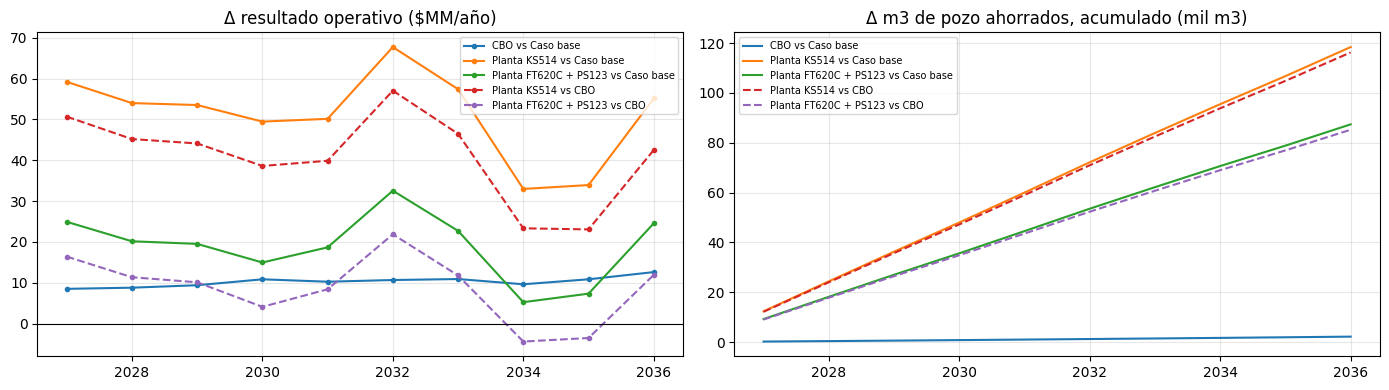

Planta KS514 vs CBO


,Δ fierro (t),Δ fierro imán (t),Δ madera (t),Δ astilla (t),Δ NO permitido al vertedero (t),Δ m3 ahorrados,Δ neto materiales ($MM),Δ OPEX ($MM),Δ mov. al pozo ($MM),Δ alimentación planta ($MM),Δ resultado operativo ($MM)
anio,,,,,,,,,,,
2027,554.00,-18.40,"1,727.70","1,209.40","-2,931.90","12,143.20",178.80,128.10,-0.80,16.00,50.70
2028,513.00,-17.50,"1,694.50","1,186.10","-2,811.10","11,839.70",173.30,128.10,-0.70,15.80,45.20
2029,506.90,-17.40,"1,702.10","1,191.40","-2,890.60","11,720.60",171.50,127.40,-0.90,15.70,44.10
2030,489.40,-15.50,"1,694.80","1,186.30","-2,736.70","11,496.20",166.60,128.00,-0.60,15.80,38.60
2031,558.60,-19.00,"1,731.00","1,211.70","-2,932.50","11,811.10",167.90,128.00,-0.80,15.90,39.90
2032,569.80,-18.00,"1,757.80","1,230.40","-2,957.50","11,929.20",185.70,128.60,-0.80,16.10,57.00
2033,506.40,-17.00,"1,709.60","1,196.70","-2,816.00","11,544.20",174.70,128.20,-0.70,16.00,46.50
2034,491.40,-16.30,"1,719.70","1,203.80","-2,807.10","11,330.70",151.10,127.70,-0.70,15.80,23.30
2035,522.40,-17.80,"1,671.40","1,170.00","-2,794.70","11,012.80",150.70,127.60,-0.70,15.70,23.10


Planta FT620C + PS123 vs CBO


,Δ fierro (t),Δ fierro imán (t),Δ madera (t),Δ astilla (t),Δ NO permitido al vertedero (t),Δ m3 ahorrados,Δ neto materiales ($MM),Δ OPEX ($MM),Δ mov. al pozo ($MM),Δ alimentación planta ($MM),Δ resultado operativo ($MM)
anio,,,,,,,,,,,
2027,368.70,-14.20,"1,390.60",973.40,"-2,274.40","9,023.50",126.30,109.90,-0.60,14.10,16.40
2028,329.90,-13.40,"1,361.30",952.90,"-2,177.20","8,756.40",121.20,109.80,-0.60,13.90,11.40
2029,325.00,-13.30,"1,370.90",959.60,"-2,259.20","8,656.20",119.30,109.20,-0.70,13.80,10.10
2030,305.80,-11.40,"1,360.60",952.40,"-2,101.50","8,403.60",113.80,109.70,-0.50,13.90,4.10
2031,373.50,-14.90,"1,394.10",975.90,"-2,296.20","8,693.40",118.10,109.70,-0.70,14.10,8.40
2032,382.50,-13.80,"1,416.80",991.80,"-2,298.10","8,774.30",132.20,110.40,-0.60,14.20,21.90
2033,320.60,-12.90,"1,371.50",960.00,"-2,170.70","8,415.50",121.80,110.00,-0.60,14.10,11.80
2034,308.50,-12.20,"1,386.80",970.80,"-2,174.00","8,250.70",105.10,109.50,-0.60,13.90,-4.40
2035,340.10,-13.90,"1,339.90",938.00,"-2,224.90","7,944.80",105.70,109.20,-0.70,13.80,-3.50


In [25]:
inc_cbo = {f"{sc['nombre']} vs CBO": delta(R_[sc['nombre']], R_['CBO']) for sc in PLANTAS.values()}
ind_cbo = pd.DataFrame([indicadores(sc['nombre'], 'CBO') for sc in PLANTAS.values()]).set_index('comparación')
display(ind_cbo.style.format('{:,.1f}').format(FMT_IND))
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for k, d_ in {**inc_base, **inc_cbo}.items():
    ls = '-' if 'Caso base' in k else '--'
    ax[0].plot(d_.index, d_['Δ resultado operativo ($MM)'], ls, marker='.', label=k); ax[1].plot(d_.index, d_['Δ m3 ahorrados'].cumsum()/1e3, ls, label=k)
ax[0].axhline(0, color='k', lw=.8); ax[0].set_title('Δ resultado operativo ($MM/año)'); ax[0].legend(fontsize=7)
ax[1].set_title('Δ m3 de pozo ahorrados, acumulado (mil m3)'); ax[1].legend(fontsize=7); plt.tight_layout(); plt.show()
for k, d_ in inc_cbo.items():
    print(k); display(d_.round(1))

#### Movimiento de material: ¿cuánto cambia con la planta?
En el caso base todo lo que llega se mueve una vez al pozo. Con planta, lo procesado se mueve dos veces (a la tolva y el rechazo al pozo), y lo recuperado ya no se mueve. La tabla compara las dos formas de modelar la alimentación, contra el caso base y contra el CBO.

In [26]:
filas = []
for k, sc in PLANTAS.items():
    for modo in ('por_tonelada', 'por_hora'):
        a = resumen(caso_planta(cr, dict(sc, alimentacion=modo))).mean()
        filas.append({'planta': sc['nombre'], 'alimentación': modo, 't al pozo/año': a.vertedero_t, 'mov. al pozo ($MM)': a.opex_mov_clp/1e6,
                      'alimentación ($MM)': a.opex_alim_clp/1e6, 'Δ resultado vs Caso base ($MM/año)': (a.resultado_clp - R_['Caso base'].resultado_clp.mean())/1e6,
                      'Δ resultado vs CBO ($MM/año)': (a.resultado_clp - R_['CBO'].resultado_clp.mean())/1e6})
print(f"Costo de mover 1 t al pozo: ${costo_mov_t():,.0f}/t")
display(pd.DataFrame(filas).style.format({c: '{:,.1f}' for c in ['mov. al pozo ($MM)', 'alimentación ($MM)', 'Δ resultado vs Caso base ($MM/año)', 'Δ resultado vs CBO ($MM/año)']} | {'t al pozo/año': '{:,.0f}'}))

Costo de mover 1 t al pozo: $262/t


,planta,alimentación,t al pozo/año,mov. al pozo ($MM),alimentación ($MM),Δ resultado vs Caso base ($MM/año),Δ resultado vs CBO ($MM/año)
0,Planta KS514,por_tonelada,"180,461",47.4,15.9,51.3,41.1
1,Planta KS514,por_hora,"180,461",47.4,41.8,25.4,15.1
2,Planta FT620C + PS123,por_tonelada,"180,970",47.5,14.0,19.1,8.8
3,Planta FT620C + PS123,por_hora,"180,970",47.5,41.8,-8.8,-19.0


### 6.7 Sensibilidad rápida de las plantas: turnos, operarios y productividad (año 1)
Muestra cuándo deja de mandar la máquina y pasan a mandar los operarios, y cómo cambia el resultado contra el caso base y contra el CBO. Con 2 turnos se duplica el personal de la planta en el OPEX (`turnos`). Con 4 operarios de picking la planta usa menos gente que los 8 actuales, así que el personal adicional puede quedar negativo (se reasignan o salen trabajadores).

In [27]:
filas = []
b_1, c_1 = R_['Caso base'].iloc[0], R_['CBO'].iloc[0]
for k, sc in PLANTAS.items():
    for turnos in (1, 2):
        for ops in (4, 8):
            for tasa in (2.9, 4.0, 7.0):
                sc2 = dict(sc, horas=T1 + (T2 if turnos == 2 else []), turnos=turnos, operarios_picking=ops, tasa_revision_th=tasa)
                c, cm, co = capacidad_th(sc2); r_ = resumen(caso_planta(cr, sc2)).iloc[0]
                filas.append(dict(planta=sc['nombre'], turnos=turnos, operarios_por_turno=ops, t_h_operario=tasa, cap_th=c, manda='máquina' if cm <= co else 'operarios',
                                  pct_procesado=r_.pct_procesado, pct_recuperado=r_.pct_recuperado,
                                  d_resultado_vs_base_MM=(r_.resultado_clp - b_1.resultado_clp)/1e6, d_resultado_vs_CBO_MM=(r_.resultado_clp - c_1.resultado_clp)/1e6))
display(pd.DataFrame(filas).style.format({'cap_th':'{:.1f}','pct_procesado':'{:.0%}','pct_recuperado':'{:.2%}','d_resultado_vs_base_MM':'{:,.1f}','d_resultado_vs_CBO_MM':'{:,.1f}'}))

,planta,turnos,operarios_por_turno,t_h_operario,cap_th,manda,pct_procesado,pct_recuperado,d_resultado_vs_base_MM,d_resultado_vs_CBO_MM
0,Planta KS514,1,4,2.900000,30.4,máquina,38%,2.27%,106.0,97.5
1,Planta KS514,1,4,4.000000,30.4,máquina,38%,2.27%,106.0,97.5
2,Planta KS514,1,4,7.000000,30.4,máquina,38%,2.27%,106.0,97.5
3,Planta KS514,1,8,2.900000,30.4,máquina,38%,2.27%,59.2,50.7
4,Planta KS514,1,8,4.000000,30.4,máquina,38%,2.27%,59.2,50.7
5,Planta KS514,1,8,7.000000,30.4,máquina,38%,2.27%,59.2,50.7
6,Planta KS514,2,4,2.900000,30.4,máquina,66%,3.93%,210.8,202.3
7,Planta KS514,2,4,4.000000,30.4,máquina,66%,3.93%,210.8,202.3
8,Planta KS514,2,4,7.000000,30.4,máquina,66%,3.93%,210.8,202.3
9,Planta KS514,2,8,2.900000,30.4,máquina,66%,3.93%,117.2,108.7


### 6.8 Sensibilidad a la densidad de lo recibido (pedida por Rodrigo)
Rodrigo: el contenedor de 9 m³ viene con ~3.000 kg (~0,33 t/m³) y el de 10 m³ con ~7.000 kg (~0,70 t/m³); el modelo pondera por la mezcla de contenedores de las guías (~0,525 t/m³). Las 118.457 t del RETC usan ~4,8 t por viaje, así que no son una calibración independiente.

Aquí se cambia la densidad media manteniendo los mismos viajes y m³: con más densidad llegan más toneladas, la planta (que limita por t/h) procesa una fracción menor y cambian los m³ ahorrados.

In [28]:
filas = []
for rho in (0.33, 0.43, round(t_viaje_medio / m3_viaje_medio, 3), 0.60, 0.70):
    cr_d = con_densidad(cr, rho)
    rb_d, rc_d = resumen(caso_base(cr_d)), resumen(caso_cbo(cr_d))
    for k, sc in PLANTAS.items():
        rp = resumen(caso_planta(cr_d, sc))
        filas.append({'densidad (t/m3)': rho, 'planta': sc['nombre'], 'entrada (t/año)': rp.entrada_t.mean(), '% procesado': rp.pct_procesado.mean(),
                      'Δ m3 ahorrados vs base': (rp.ahorro_m3 - rb_d.ahorro_m3).mean(), 'años pozo ganados vs base': anios_pozo(rp, rb_d),
                      'Δ resultado vs base ($MM/año)': (rp.resultado_clp - rb_d.resultado_clp).mean()/1e6,
                      'Δ resultado vs CBO ($MM/año)': (rp.resultado_clp - rc_d.resultado_clp).mean()/1e6})
t_dens = pd.DataFrame(filas)
display(t_dens.style.format({'densidad (t/m3)': '{:.3f}', 'entrada (t/año)': '{:,.0f}', '% procesado': '{:.1%}', 'Δ m3 ahorrados vs base': '{:,.0f}',
                             'años pozo ganados vs base': '{:.2f}', 'Δ resultado vs base ($MM/año)': '{:,.1f}', 'Δ resultado vs CBO ($MM/año)': '{:,.1f}'}))

,densidad (t/m3),planta,entrada (t/año),% procesado,Δ m3 ahorrados vs base,años pozo ganados vs base,Δ resultado vs base ($MM/año),Δ resultado vs CBO ($MM/año)
0,0.330,Planta KS514,"115,890",52.5%,"12,896",0.37,43.7,40.8
1,0.330,Planta FT620C + PS123,"115,890",46.3%,"9,797",0.28,11.5,8.6
2,0.430,Planta KS514,"151,008",40.3%,"12,361",0.32,47.7,41.0
3,0.430,Planta FT620C + PS123,"151,008",35.6%,"9,259",0.24,15.4,8.7
4,0.525,Planta KS514,"184,370",33.0%,"11,838",0.31,51.4,41.1
5,0.525,Planta FT620C + PS123,"184,370",29.1%,"8,735",0.24,19.1,8.8
6,0.600,Planta KS514,"210,708",28.9%,"11,424",0.31,54.3,41.2
7,0.600,Planta FT620C + PS123,"210,708",25.5%,"8,321",0.23,22.0,8.9
8,0.700,Planta KS514,"245,826",24.8%,"10,874",0.30,58.2,41.3
9,0.700,Planta FT620C + PS123,"245,826",21.9%,"7,769",0.22,25.8,8.9


### Lectura de resultados (v0.8, semilla 42; cambia si se cambian los supuestos)
**Validación.** El caso base reproduce las ventas de reciclaje (simulado $122 MM vs $122 MM anualizado 2026) y la madera a RECUPAC (133 vs 140 t). Recupera 0,4% de lo recibido, contra el 0,7% medido por Rodrigo en 2025. Esas 875 t incluyen material separado que no se vende de inmediato.

**Todos contra el caso base (1 turno):**
- **CBO:** +$10 MM/año con $48 MM de inversión (payback ~5 años). El imán es lo que aporta; la chipeadora con la madera actual no se paga.
- **KS514:** +$51 MM/año con ~$1.280 MM (payback ~25 años). Sube la recuperación de 0,4% a 2,0% de lo recibido.
- **FT620C+PS123:** +$19 MM/año con ~$790 MM (payback ~41 años). Recuperación 1,65%.
- **Pozo:** con 1 turno la planta procesa ~1/3 de lo que llega y ahorra ~12 mil m³/año. En 10 años eso alarga la vida del pozo en solo ~0,3 años (~4 meses), porque los inertes procesados vuelven al pozo como rechazo. Para recuperar la inversión en 10 años sin descontar, cada m³ ahorrado tendría que valer ~$6.500-6.900.
- **Costo por t procesada:** ~$4.400/t (KS514) y ~$3.700/t (FT620C), contra ~$260/t que cuesta hoy mover 1 t al pozo más el valor del espacio, que está pendiente.

**Plantas contra el CBO:** KS514 +$41 MM/año (payback ~30 años); FT620C +$9 MM/año (~84 años).

**Riesgo (Monte Carlo, 10 años).** Ya incluye el riesgo de perder a Ecociclo. P(resultado operativo acumulado < 0): CBO 12%, KS514 32%, FT620C 48% contra el caso base.

**Lo que más mueve el resultado:**
1. **Segundo turno** con 4 operarios por turno: +$210 MM el año 1 en la KS514 (§6.7).
2. **Valorizar inertes como árido**, que hoy vuelven al pozo como rechazo. Es lo que Rodrigo marca como beneficio central y todavía no está en el modelo.
3. **Valor del m³ de pozo.**
4. **Forma de alimentar la planta:** con un cargador dedicado, la KS514 cae a +$25 MM/año.

**Densidad.** Entre 0,33 y 0,70 t/m³ cambia cuántas toneladas llegan (116-246 mil t/año) y el % procesado (52% → 25%), pero el resultado contra el CBO casi no cambia, porque la planta procesa las mismas t/h.

**Energía (cotizaciones):** KS514 37 kW y FT620C+PS123 46 kW, es decir ~1,0 y ~1,4 kWh/t, bajo el rango de Ferronato (1,45-4,52 kWh/t) que usó Pedro. La FT620C puede operar con su generador (9,5 L/h) si no hay empalme.

## 7. Monte Carlo: incrementales con números aleatorios comunes
Cada corrida sortea otra historia (llegadas, contenido, precios con riesgo de perder al comprador) y aplica todos los escenarios a esa misma historia. Se reportan los totales en 10 años: P10 / P50 / P90 y la probabilidad de que el resultado operativo incremental sea negativo. Primero contra el caso base y después las plantas contra el CBO.

Totales en 10 años (P10 / P50 / P90):


d_fierro_t                   d_noperm_t  \
                                         0.10     0.50     0.90       0.10   
comparacion                                                                  
CBO vs Caso base                       323.00   710.00 1,079.00  -1,079.00   
Planta KS514 vs Caso base             -294.00 4,190.00 8,428.00 -31,920.00   
Planta FT620C + PS123 vs Caso base  -1,177.00 2,646.00 6,233.00 -25,117.00   
Planta KS514 vs CBO                   -622.00 3,482.00 7,353.00 -31,071.00   
Planta FT620C + PS123 vs CBO        -1,494.00 1,931.00 5,158.00 -24,230.00   

                                                              d_m3            \
                                         0.50       0.90      0.10      0.50   
comparacion                                                                    
CBO vs Caso base                      -709.00    -323.00    791.00  1,735.00   
Planta KS514 vs Caso base          -23,527.00 -16,988.00 68,595.00 99,487.00   
Planta FT620C + PS123 vs Caso base -18,232.00 -12,818.00 49,389.00 72,234.00   
Planta KS514 vs CBO                -22,746.00 -16,229.00 67,513.00 97,746.00   
Planta FT620C + PS123 vs CBO       -17,426.00 -12,097.00 48,102.00 70,542.00   

                                              d_neto_MM                    \
                                         0.90      0.10     0.50     0.90   
comparacion                                                                 
CBO vs Caso base                     2,640.00     78.00   152.00   224.00   
Planta KS514 vs Caso base          134,596.00    789.00 1,692.00 2,579.00   
Planta FT620C + PS123 vs Caso base  97,801.00    446.00 1,209.00 1,952.00   
Planta KS514 vs CBO                132,159.00    680.00 1,526.00 2,358.00   
Planta FT620C + PS123 vs CBO        95,341.00    349.00 1,041.00 1,732.00   

                                   d_opex_MM                   d_resultado_MM  \
                                        0.10     0.50     0.90           0.10   
comparacion                                                                     
CBO vs Caso base                       80.00    80.00    81.00          -2.00   
Planta KS514 vs Caso base           1,360.00 1,362.00 1,364.00        -574.00   
Planta FT620C + PS123 vs Caso base  1,177.00 1,179.00 1,180.00        -735.00   
Planta KS514 vs CBO                 1,279.00 1,281.00 1,283.00        -602.00   
Planta FT620C + PS123 vs CBO        1,097.00 1,098.00 1,100.00        -750.00   

                                                    
                                     0.50     0.90  
comparacion                                         
CBO vs Caso base                    72.00   144.00  
Planta KS514 vs Caso base          329.00 1,217.00  
Planta FT620C + PS123 vs Caso base  30.00   774.00  
Planta KS514 vs CBO                244.00 1,077.00  
Planta FT620C + PS123 vs CBO       -58.00   633.00

P(Δ resultado operativo 10 años < 0):


,P(<0)
comparacion,
CBO vs Caso base,12%
Planta KS514 vs Caso base,32%
Planta FT620C + PS123 vs Caso base,48%
Planta KS514 vs CBO,32%
Planta FT620C + PS123 vs CBO,57%


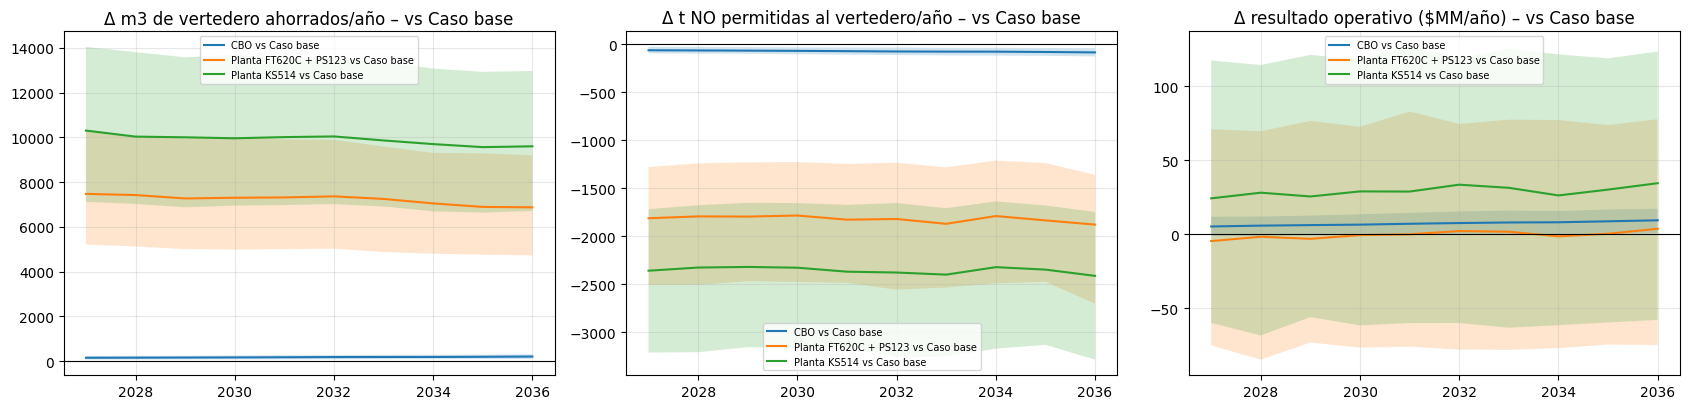

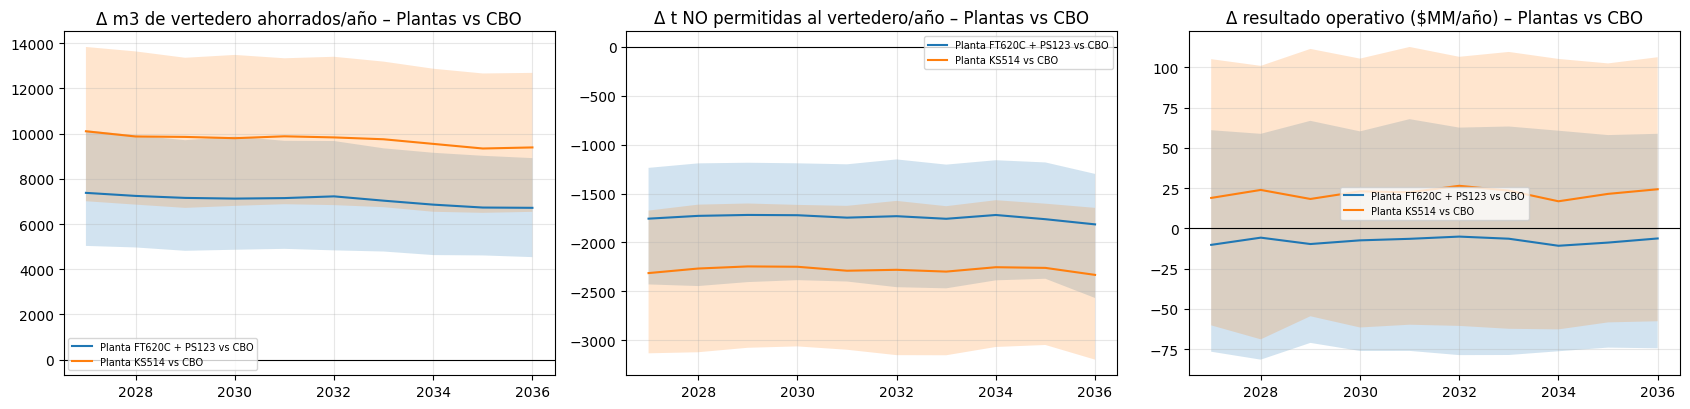

In [29]:
N_MC = SIM['n_montecarlo']
filas = []
def fila_mc(i, nombre, r_, r0):
    return pd.DataFrame({'corrida': i, 'comparacion': nombre, 'anio': r_.index, 'pct_procesado': r_.pct_procesado,
        'd_fierro_t': r_.fierro_t - r0.fierro_t, 'd_noperm_t': r_.vert_noperm_t - r0.vert_noperm_t, 'd_m3': r_.ahorro_m3 - r0.ahorro_m3,
        'd_neto_MM': (r_.neto_clp - r0.neto_clp)/1e6, 'd_opex_MM': (r_.opex_clp - r0.opex_clp)/1e6,
        'd_resultado_MM': (r_.resultado_clp - r0.resultado_clp)/1e6}).reset_index(drop=True)
for i in range(N_MC):
    cr_i = preparar_corrida(SIM['semilla'] + 1 + i)
    rb_i, rc_i = resumen(caso_base(cr_i)), resumen(caso_cbo(cr_i))
    filas.append(fila_mc(i, 'CBO vs Caso base', rc_i, rb_i))
    for k, sc in PLANTAS.items():
        rp_i = resumen(caso_planta(cr_i, sc))
        filas.append(fila_mc(i, f"{sc['nombre']} vs Caso base", rp_i, rb_i))
        filas.append(fila_mc(i, f"{sc['nombre']} vs CBO", rp_i, rc_i))
mc = pd.concat(filas)
tot = mc.groupby(['comparacion','corrida'])[['d_fierro_t','d_noperm_t','d_m3','d_neto_MM','d_opex_MM','d_resultado_MM']].sum()
q = tot.groupby('comparacion').quantile([.1, .5, .9]).unstack()
orden = ['CBO vs Caso base'] + [f"{sc['nombre']} vs Caso base" for sc in PLANTAS.values()] + [f"{sc['nombre']} vs CBO" for sc in PLANTAS.values()]
q = q.loc[orden]
print('Totales en 10 años (P10 / P50 / P90):'); display(q.round(0))
print('P(Δ resultado operativo 10 años < 0):'); display(tot.groupby('comparacion').d_resultado_MM.apply(lambda x: (x < 0).mean()).loc[orden].to_frame('P(<0)').style.format('{:.0%}'))
for titulo, filtro in [('vs Caso base', 'Caso base'), ('Plantas vs CBO', 'vs CBO')]:
    fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
    for a_, col, t_ in [(ax[0],'d_m3','Δ m3 de vertedero ahorrados/año'), (ax[1],'d_noperm_t','Δ t NO permitidas al vertedero/año'), (ax[2],'d_resultado_MM','Δ resultado operativo ($MM/año)')]:
        for pl, gq in mc[mc.comparacion.str.endswith(filtro)].groupby('comparacion'):
            qq = gq.groupby('anio')[col].quantile([.1, .5, .9]).unstack()
            a_.fill_between(qq.index, qq[.1], qq[.9], alpha=.2); a_.plot(qq.index, qq[.5], label=pl)
        a_.axhline(0, color='k', lw=.8); a_.set_title(f'{t_} – {titulo}'); a_.legend(fontsize=7)
    plt.tight_layout(); plt.show()

## 8. Exportar

In [30]:
with pd.ExcelWriter('modelo_regemac_resultados.xlsx') as w:
    pd.Series({**{f'SIM.{k}': v for k, v in SIM.items()}, **{f'LLEG.{k}': v for k, v in LLEG.items()}, **{f'PLANTA.{p}.{k}': str(v) for p, sc in PLANTAS.items() for k, v in sc.items()},
               **{f'BASE.{k}': str(v) for k, v in BASE.items()}, **{f'CBO.{k}': str(v) for k, v in CBO.items()}, **{f'MERCADO.{k}': str(v) for k, v in MERCADO.items()},
               **{f'COSTOS.{k}': v for k, v in COSTOS.items()}, **{f'MOVIMIENTO.{k}': v for k, v in MOVIMIENTO.items()}, **{f'MADERA.{k}': str(v) for k, v in MADERA.items()},
               'COMP.contenido': str(COMP['contenido']), 'PERMITIDO_VERTEDERO': str(PERMITIDO_VERTEDERO), 'DENS': str(DENS)}).to_frame('valor').to_excel(w, sheet_name='parametros')
    for k, o in ESC.items(): resumen(o).to_excel(w, sheet_name=k[:28])
    for k, d_ in {**inc_base, **inc_cbo}.items(): d_.to_excel(w, sheet_name=('inc ' + k)[:31])
    pd.concat([ind_base, ind_cbo]).to_excel(w, sheet_name='indicadores')
    t_dens.to_excel(w, sheet_name='sens_densidad', index=False)
    tm.to_excel(w, sheet_name='opciones_madera', index=False)
    q.to_excel(w, sheet_name='montecarlo_incremental')
    pd.Series({**{f'POZO.{k}': v for k, v in POZO.items()}}).to_frame('valor').to_excel(w, sheet_name='pozo')
    estac.to_frame('factor').to_excel(w, sheet_name='estacionalidad')
    pd.DataFrame({'lun_vie': perfil_lv, 'sabado': perfil_sab}).to_excel(w, sheet_name='perfil_horario')
    tabla_kgv.to_excel(w, sheet_name='kg_por_viaje_hist')
print('Guardado: modelo_regemac_resultados.xlsx')

Guardado: modelo_regemac_resultados.xlsx


## Próximos pasos
- **Módulo 4 – Finanzas:** FCL real en UF (CAPEX en el año 0, depreciación SII, impuesto 27% o 25%, capital de trabajo, valor residual), VAN para tasas de 6-12% real (Damodaran), P10/P50/P90, P(VAN<0), costo por t procesada, años de pozo ganados y valor del m³ de pozo.
- **Alinear con el equipo:** entrada anual (129 mil vs ~158 mil t), régimen tributario y quién usa qué composición (6% fierro).

**Datos pendientes:**
- Capacidad de la FT620C+PS123 y ajuste de la KS514 por densidad (Osvaldo Pardo, SKC); cotizaciones vigentes y tipo de cambio GBP.
- Precio del imán a batería (cotizar). Arriendo Raico: ¿incluye operador, diésel y traslado?
- Precio de la astilla y flete a Arauco.
- Granulometría real; pesajes de la romana cuando esté mejorada.
- Movimiento de material: ¿cuántas horas de retro o cargador se usan hoy para mover lo recibido al pozo (para calibrar el $/t)? ¿Qué tamaño de acopio aceptan? ¿Cuánto se compacta el material en el pozo?
- Destino y costo del rechazo no permitido (yeso).
- Valor del m³ de pozo, m³ disponibles y compactación (`POZO`).
- Empalme eléctrico disponible (kVA) o si la planta operaría con generador.